# **Decision Tree & Random Forest**

На данных по индивидам [Российского мониторинга экономического положения и здоровья населения НИУ ВШЭ](https://www.hse.ru/rlms/) за [2024 год (33 волна)](https://www.hse.ru/rlms/spss) попробуем на основании деревьев решений и случайного леса построить модель прогноза размера заработной платы (более 30 тыс. руб.? да - 0/нет - 1) физического лица по его социально-экономическим характеристикам.

In [450]:
# Ипортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.utils import shuffle # для перемешивания данных

from sklearn.tree import DecisionTreeClassifier # для классификации деревом решений
from sklearn.tree import plot_tree # для визуализации дерева
from sklearn.ensemble import RandomForestClassifier # для классификации через случайный лес
from sklearn.dummy import DummyClassifier # baseline модели

from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [451]:
# Изменим значение максимального количества отображаемых строк и столбцов
pd.options.display.max_columns = 50
pd.options.display.max_rows = 100
# Поменяем формат вывода чисел: разделим разряды запятой и будем выводить два знака после точки
pd.options.display.float_format = '{:,.2f}'.format

In [452]:
# Зададим параметры, которые будут использоваться в расчетах ниже.
random_state=12345

# Для расшифровки полей датасета исп. https://www.hse.ru/rlms/code ф. "Описание переменных файла данных по индивидам" для Волна 33 (2024 г.)
# Список используемых колонок
features = ['ccid_i', 'cc_int_y', 'cch5', 'cc_age', 'cc_marst', 'ccj72_171', 'ccj72_172', 'ccj72_173', 'cc_diplom', \
         'ccj260', 'ccj262', 'ccj161_3y', 'ccj161_3m', 'ccj5a', 'ccj5b', 'ccj6_2', 'region', 'status', 'cc_occup08', \
         'ccj4_1', 'ccj6', 'ccj6_0', 'ccj11', 'ccj13', 'ccj23', 'ccm20_7', 'ccj77', 'ccj90', 'ccs7', 'ccj10']

# Словарь для кодирования переменной "Пол респондента" (cch5)
cch5_d = {1: "male", 2: "female"}
# Словарь для кодирования переменной "Семейное положение" (cc_marst)
cc_marst_d = {
    1: "Никогда в браке не состояли",
    2: "Состоите в зарегистрированном браке",
    3: "Живете вместе, но не зарегистрированы",
    4: "Разведены и в браке не состоите",
    5: "Вдовец (вдова)",
    6: "Официально зарегистрированы, но вместе не проживают",
    99999997: "ЗАТРУДНЯЮСЬ ОТВЕТИТЬ",
    99999998: "ОТКАЗ ОТ ОТВЕТА",
    99999999: "НЕТ ОТВЕТА"
}
# Словарь 2 для кодирования переменной "Семейное положение" (cc_marst)
cc_marst_d_f = {
    1: "not_married",
    2: "married",
    3: "not_married",
    4: "not_married",
    5: "not_married",
    6: "married",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "Наличие детей" (ccj72_171)
ccj72_171_d = {1: "yes", 2: "no", 99999997: "unknown", 99999998: "unknown", 99999999: "unknown"}
# Словарь для кодирования переменной "Образование (группа)" (cc_diplom)
cc_diplom_d = {
    1: "окончил 0 - 6 классов",
    2: "незаконченное среднее образование (7 - 8 кл)",
    3: "незаконченное среднее образов. (7 - 8 кл) + что-то еще",
    4: "законченное среднее образование",
    5: "законченное среднее специальное образование",
    6: "законченное высшее образование и выше",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь 2 для кодирования переменной "Образование (группа)" (cc_diplom)
cc_diplom_d_f = {
    1: "no",
    2: "no",
    3: "no",
    4: "no",
    5: "no",
    6: "yes",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "законченное бразование" (cc_educ)
diplom_years_map = {
    1: 6,   # окончил 0–6 классов
    2: 8,   # незаконченное среднее (7–8 кл)
    3: 9,   # незаконченное среднее (7–8 кл) + что-то ещё
    4: 11,  # законченное среднее образование
    5: 13,  # законченное среднее специальное образование
    6: 16,  # законченное высшее образование и выше
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "Владение иностранным языком" (ccj260 )
ccj260_d = {
    1: "yes",
    2: "no",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "Тип населенного пункта" (status)
status_d = {1: "center_area", 2: "city", 3: "urban_village", 4: "village"}
# Словарь для кодирования переменной "Профессиональная группа" (cc_occur08)
cc_occur08 = {
    0: "военнослужащие",
    1: "законодатели; крупные чиновники; руководители высш. и сред. звена",
    2: "специалисты высшего уровня квалификации",
    3: "специалисты среднего уровня квалификации; чиновники",
    4: "служащие офисные и по обслуживанию клиентов",
    5: "работники сферы торговли и услуг",
    6: "квалифицированные работники сельского, лесного хоз-ва и рыбоводства",
    7: "квалифицированные рабочие, занятые ручным трудом",
    8: "квалифицированные рабочие, использующие машины и механизмы",
    9: "неквалифицированные рабочие всех отраслей",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "Наличие подчиненных" (ccj6)
ccj6_d = {
    1: "yes",
    2: "no",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}
# Словарь для кодирования переменной "Тип занятости" (ccj11)
ccj11_d = {
    1: "enterprise",
    2: "not_enterprise",
    3: "self_employed",
    4: "individual",
    99999997: "unknown",
    99999998: "unknown",
    99999999: "unknown"
}

## **Сбор данных**

In [453]:
%%time
# Загрузим датасет с GitHub
url = "https://raw.githubusercontent.com/eilicheva-art/datasets/refs/heads/main/ind_rlms_2024.csv"
df = pd.read_csv(url, on_bad_lines='skip', sep=';')
# Оставим только нужные колонки
df = df[features]
# Выведим первые 5 строк датафрейма
df.head()

CPU times: user 1.87 s, sys: 213 ms, total: 2.09 s
Wall time: 3.66 s


,ccid_i,cc_int_y,cch5,cc_age,cc_marst,ccj72_171,ccj72_172,ccj72_173,cc_diplom,ccj260,ccj262,ccj161_3y,ccj161_3m,ccj5a,ccj5b,ccj6_2,region,status,cc_occup08,ccj4_1,ccj6,ccj6_0,ccj11,ccj13,ccj23,ccm20_7,ccj77,ccj90,ccs7,ccj10
0,"1,008,401.00","2,025.00",2.00,66.00,2.00,1.00,3.00,0.00,4.00,2.00,NaN,41.00,1.00,NaN,NaN,NaN,1.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,4.00,1.00,NaN
1,"1,008,801.00","2,025.00",2.00,71.50,5.00,1.00,3.00,0.00,4.00,2.00,NaN,40.00,0.00,NaN,NaN,NaN,1.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,4.00,1.00,NaN
2,"1,008,901.00","2,025.00",2.00,62.50,5.00,1.00,2.00,0.00,4.00,2.00,NaN,29.00,0.00,NaN,NaN,NaN,1.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,4.00,1.00,NaN
3,"1,010,801.00","2,024.00",2.00,61.00,2.00,1.00,3.00,0.00,4.00,2.00,NaN,42.00,0.00,"2,023.00",11.00,"99,999,997.00",1.00,4.00,5.00,2.00,2.00,NaN,1.00,150.00,"99,999,997.00",2.00,1.00,12.00,1.00,"22,000.00"
4,"1,010,802.00","2,024.00",1.00,55.50,2.00,1.00,3.00,0.00,4.00,2.00,NaN,35.00,0.00,"2,024.00",7.00,45.00,1.00,4.00,5.00,2.00,2.00,NaN,1.00,"99,999,997.00",1.00,2.00,1.00,12.00,1.00,"50,000.00"


In [454]:
# Выведим общую информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ccid_i      12000 non-null  float64
 1   cc_int_y    12000 non-null  float64
 2   cch5        12000 non-null  float64
 3   cc_age      12000 non-null  float64
 4   cc_marst    10303 non-null  float64
 5   ccj72_171   10303 non-null  float64
 6   ccj72_172   7445 non-null   float64
 7   ccj72_173   7445 non-null   float64
 8   cc_diplom   10303 non-null  float64
 9   ccj260      10303 non-null  float64
 10  ccj262      1823 non-null   float64
 11  ccj161_3y   9107 non-null   float64
 12  ccj161_3m   8356 non-null   float64
 13  ccj5a       5387 non-null   float64
 14  ccj5b       5387 non-null   float64
 15  ccj6_2      5387 non-null   float64
 16  region      12000 non-null  float64
 17  status      12000 non-null  float64
 18  cc_occup08  5387 non-null   float64
 19  ccj4_1      5387 non-null

Итак, для построения модели предсказания заработной платы собрали 28 колонок, из них

 - фичи (23 шт.): `cch5` - пол респондента; `cc_age` - возраст респондента;  `cc_marst` - семейное положение; `ccj72_171` - есть ли дети; `ccj72_172` - количество детей; `ccj72_173` - количество детей моложе 18 лет; `cc_diplom` - законченное образование (группа);  `ccj260` -  владение иностранным языком; `ccj262` - степень владения иностранным языком; `ccj161_3y` - стаж всего (лет); `ccj161_3m` - стаж всего (мес); `ccj5a` - стаж на текущем месте работы (лет); `ccj5b` - стаж на текущем месте работы (мес); `ccj6_2` -средняя продолжительность рабочей недели; `region` - регион; `status` - тип населенного пункта; `cc_occup08` - профессиональная группа; `ccj4_1` - в какой отрасли вы работаете на этой работе?; `ccj6_0` - количество подчиненных; `ccj6` -у вас есть подчиненные на этой работе?; `ccj11` - тип занятости (организация/самозанятость); `ccj13` - сколько человек работает на вашем предприятии? если не знаете точно, скажите примерно; `ccj23` - является государство владельцем или совладельцем вашего предприятия, организации?.

 - варианты таргета (1 шт.): `ccj10` - зарплата за последние 30 дней по основной работе (после вычета налогов).

 - переменные для фильтрации (4 шт.): `ccm20_7` - какая группа инвалидности вам назначена?; `ccj77` - есть ли работа у респондента?; `ccj90` - какой ответ лучше всего описывает ваше основное занятие в настоящее время?; `ccs7` - отметьте, насколько по-вашему мнению надежна получаемая информация.

In [455]:
# Проведем предварительную фильтрацию датафрейма
df = df[df['ccm20_7']==2] # отфильтруем неинвалидов
df = df[df['ccj77']==1] # отфильтруем только имеющих работу
df = df[(df['ccj90']>=10)&(df['ccj90']<=13)] # отфильтруем только работающих, предпринемателей, фермеров (исключим учеников, пенсионеров, студентов, ...)
df = df[df['ccs7']==1] # отфильтруем только надежную информацию
# Удалим далее неинформативные столбцы
del df['ccm20_7']
del df['ccj77']
del df['ccj90']
del df['ccs7']
# Выведим первые 5 строк датафрейма
df.head()

,ccid_i,cc_int_y,cch5,cc_age,cc_marst,ccj72_171,ccj72_172,ccj72_173,cc_diplom,ccj260,ccj262,ccj161_3y,ccj161_3m,ccj5a,ccj5b,ccj6_2,region,status,cc_occup08,ccj4_1,ccj6,ccj6_0,ccj11,ccj13,ccj23,ccj10
3,"1,010,801.00","2,024.00",2.00,61.00,2.00,1.00,3.00,0.00,4.00,2.00,NaN,42.00,0.00,"2,023.00",11.00,"99,999,997.00",1.00,4.00,5.00,2.00,2.00,NaN,1.00,150.00,"99,999,997.00","22,000.00"
4,"1,010,802.00","2,024.00",1.00,55.50,2.00,1.00,3.00,0.00,4.00,2.00,NaN,35.00,0.00,"2,024.00",7.00,45.00,1.00,4.00,5.00,2.00,2.00,NaN,1.00,"99,999,997.00",1.00,"50,000.00"
5,"1,010,803.00","2,024.00",1.00,43.00,1.00,2.00,NaN,NaN,3.00,2.00,NaN,10.00,0.00,"2,024.00",9.00,"99,999,997.00",1.00,4.00,7.00,"99,999,999.00",2.00,NaN,1.00,"99,999,997.00",1.00,NaN
9,"9,000,503.00","2,024.00",2.00,37.50,2.00,1.00,1.00,1.00,6.00,1.00,3.00,18.00,0.00,"2,023.00",5.00,40.00,9.00,1.00,3.00,11.00,2.00,NaN,1.00,20.00,1.00,"45,000.00"
12,"9,005,501.00","2,024.00",2.00,59.50,4.00,1.00,2.00,0.00,5.00,2.00,NaN,33.00,0.00,"1,991.00",9.00,40.00,9.00,1.00,5.00,14.00,2.00,NaN,4.00,NaN,NaN,"60,000.00"


In [456]:
# Выведим количество строк датафрейма после фильтрации
print("Количество строк:", df.shape[0])
# Выведим количество уникальных id респондентов
print("Количество уникальных респондентов:", len(df['ccid_i'].unique()))

Количество строк: 5047
Количество уникальных респондентов: 5047


## **Предобработка данных**

### **Изучение отдельных признаков**

#### **Выбор таргета**

##### **ccj10 (зарплата за последние 30 дней по основной работе)**

In [457]:
# Выведим статистику по различным пропускам переменной ccj10
print(df[df['ccj10'] == 99999997].shape[0]) # ЗАТРУДНЯЮСЬ ОТВЕТИТЬ
print(df[df['ccj10'] == 99999998].shape[0]) # ОТКАЗ ОТ ОТВЕТА
print(df[df['ccj10'] == 99999999].shape[0]) # НЕТ ОТВЕТА
print(df[df['ccj10'].isnull()==True].shape[0]) # не заполнено

15
110
15
91


In [458]:
# Заполним пропуски
df.loc[df['ccj10'].isnull()==True, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999997, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999998, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999999, 'ccj10'] = 'unknown'

In [459]:
# Проверка
print(df[df['ccj10'].isnull()==True].shape[0])
print(df[df['ccj10']=='unknown'].shape[0])

0
231


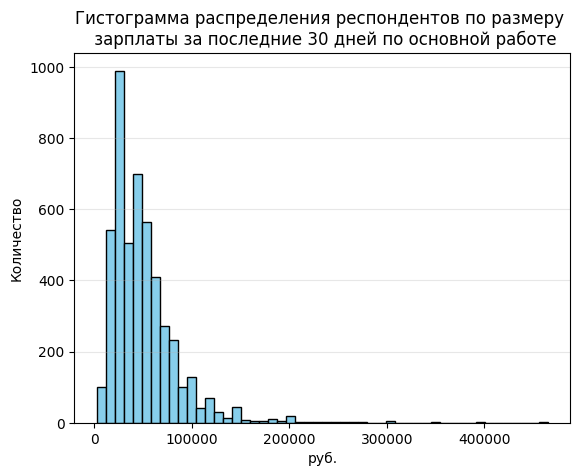

In [460]:
# Построим гистограмму ccj10
plt.hist(df[df['ccj10']!='unknown']['ccj10'], bins=50, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по размеру \n зарплаты за последние 30 дней по основной работе')
plt.xlabel('руб.')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)
plt.show();

Переменная содержит 231 пропуск (категория "unknown").

In [461]:
# Удалим в df строки, где ccj10 == 'unknown'
df = df[df['ccj10']!='unknown']
df['ccj10'] = df['ccj10'].astype('float') # изменим тип данных
# Выведим количество строк датафрейма после удаления пропусков по выбранному таргету
df.shape[0]

4816

In [462]:
# Выведим описательные статистики таргета
df['ccj10'].describe()

,ccj10
count,"4,816.00"
mean,"49,910.56"
std,"35,083.73"
min,"3,000.00"
25%,"28,000.00"
50%,"40,000.00"
75%,"60,000.00"
max,"465,000.00"


In [463]:
# Закодируем целевую переменную (1 - зп менее 30 тыс. руб., 0 - зп более 30 тыс. руб)
df['ccj10_cat'] = np.where(df['ccj10'] <= 30000, 1, 0)
# Выведим содержимое столбца ccj10_cat
df['ccj10_cat'].value_counts(normalize=True)

,proportion
ccj10_cat,
0,0.66
1,0.34


Видим, что имеющаяся выборка не сбалансирована, в данных преобладают респонденты с зп более 30 тыс. руб. за последние 30 дней. Дисбаланс присутствует, но он не выглядит критической проблемой, как, например если один класс состовляет 99%, а другой - 1%.

#### **Изучение и предобработка фичей**

##### **cch5 (пол)**

In [464]:
# Категоризуем переменную cch5 с помощью словаря cch5_d
df['cch5_cat'] = df['cch5'].map(cch5_d)
# Удалим переменную cch5
del df['cch5']
# Выведим содержимое столбца cch5_cat
print(df['cch5_cat'].value_counts())

cch5_cat
female    2531
male      2285
Name: count, dtype: int64


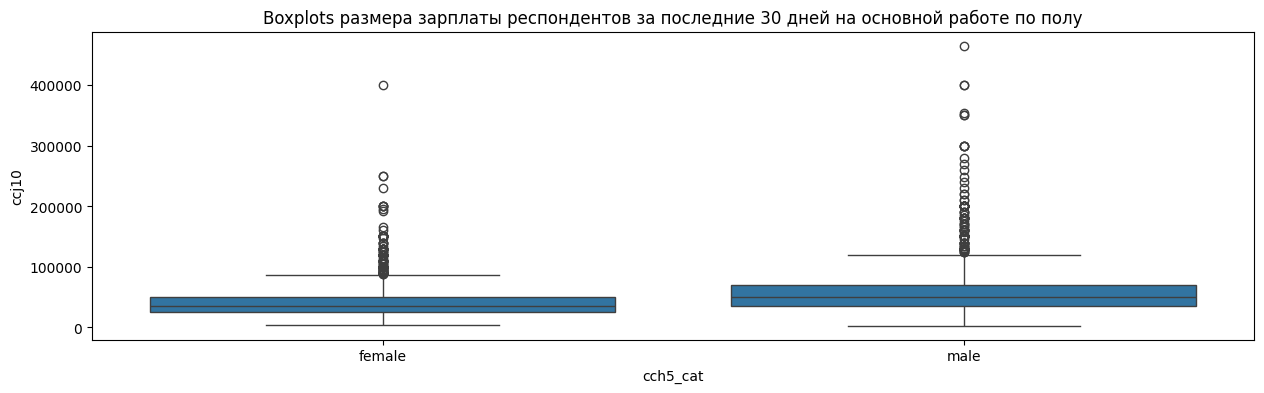

In [465]:
# Построим ящичковые диаграммы распределения зп по cch5_cat
plt.figure(figsize=(15, 4))
sns.boxplot(x='cch5_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по полу')
plt.xlabel('cch5_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Пол". Переменная не содержит пропусков. В дальнейшем перед моделированием применим OneHotEncoder для получения дамми.

##### **cc_age (возраст)**

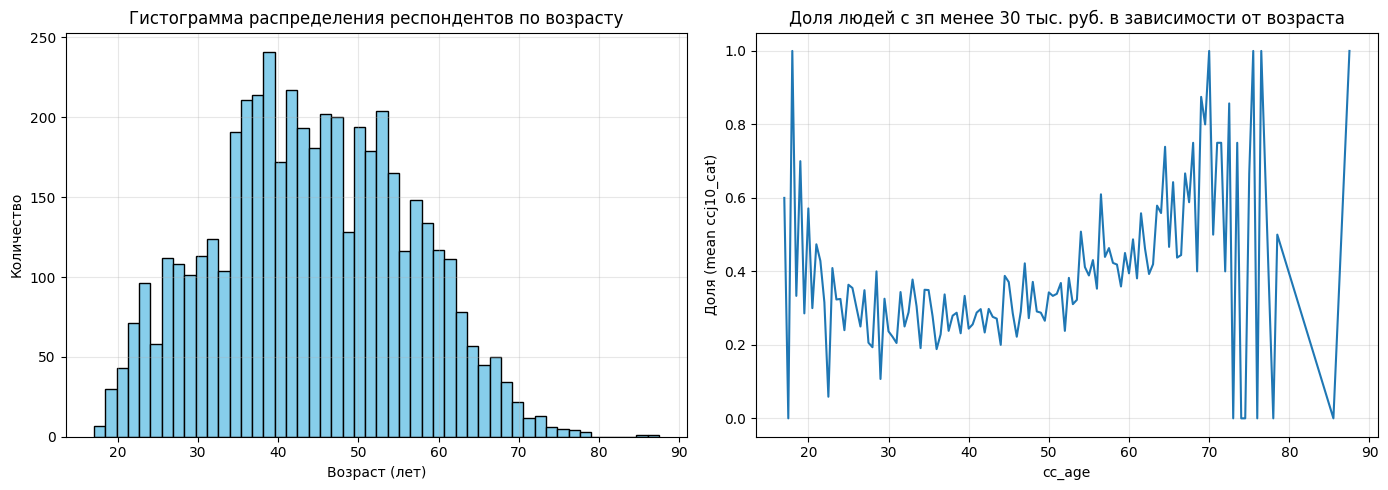

In [466]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df['cc_age'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по возрасту')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df.pivot_table(index='cc_age', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от возраста')
axes[1].set_xlabel('cc_age')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **cc_marst (семейное положение)**

In [467]:
# Категоризуем переменную cc_marst
df['cc_marst_cat'] = df['cc_marst'].map(cc_marst_d)
# Выведим содержимое столбца cc_marst
print(df['cc_marst_cat'].value_counts())

cc_marst_cat
Состоите в зарегистрированном браке                    2657
Никогда в браке не состояли                             820
Живете вместе, но не зарегистрированы                   543
Разведены и в браке не состоите                         508
Вдовец (вдова)                                          245
Официально зарегистрированы, но вместе не проживают      29
ОТКАЗ ОТ ОТВЕТА                                           9
ЗАТРУДНЯЮСЬ ОТВЕТИТЬ                                      4
НЕТ ОТВЕТА                                                1
Name: count, dtype: int64


In [468]:
# Категоризуем итогово переменную cc_marst (married/not_married)
df['cc_marst_cat'] = df['cc_marst'].map(cc_marst_d_f)
# Заполним пропуски
df.loc[df['cc_marst'].isnull()==True, 'cc_marst_cat'] = 'unknown'
# Удалим переменную cc_marst
del df['cc_marst']
# Выведим содержимое столбца cc_marst_cat
print(df['cc_marst_cat'].value_counts())

cc_marst_cat
married        2686
not_married    2116
unknown          14
Name: count, dtype: int64


In [469]:
# Проверка
df[df['cc_marst_cat'].isnull()==True].shape[0]

0

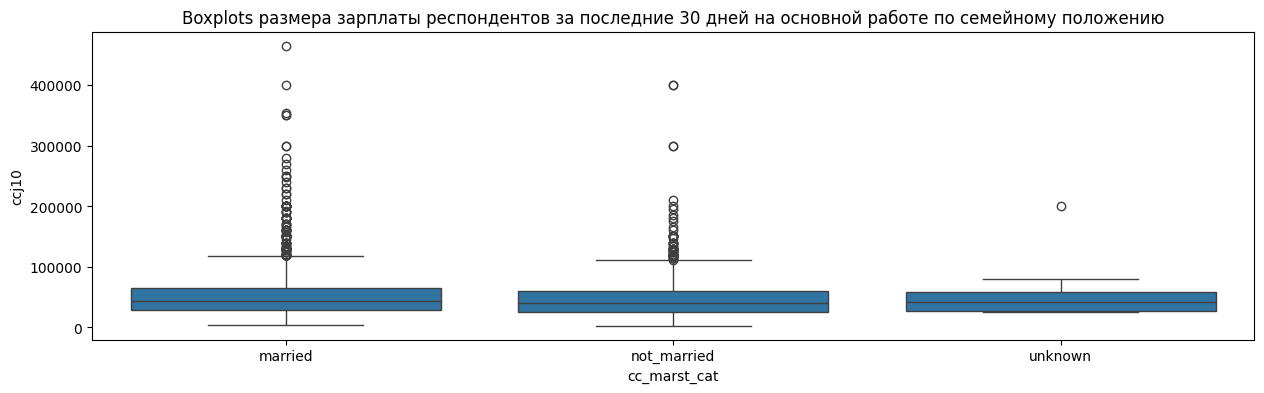

In [470]:
# Построим ящичковые диаграммы распределения зп по cch5_cat
plt.figure(figsize=(15, 4))
sns.boxplot(x='cc_marst_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по семейному положению')
plt.xlabel('cc_marst_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Семейное положение". Переменная содержит 14 пропусков (категория "unknown"). В дальнейшем перед моделированием переменной применим OneHotEncoder для получения дамми.

##### **ccj72_171 (есть ли дети)**

In [471]:
# Категоризуем переменную ccj72_171
df['ccj72_171_cat'] = df['ccj72_171'].map(ccj72_171_d)
# Заполним пропуски 'no'
df.loc[df['ccj72_171'].isnull()==True, 'ccj72_171_cat'] = 'no'
# Удалим переменную ccj72_171
del df['ccj72_171']
# Выведим содержимое столбца ccj72_171_cat
print(df['ccj72_171_cat'].value_counts())

ccj72_171_cat
yes        3605
no         1208
unknown       3
Name: count, dtype: int64


In [472]:
# Проверка
df[df['ccj72_171_cat'].isnull()==True].shape[0]

0

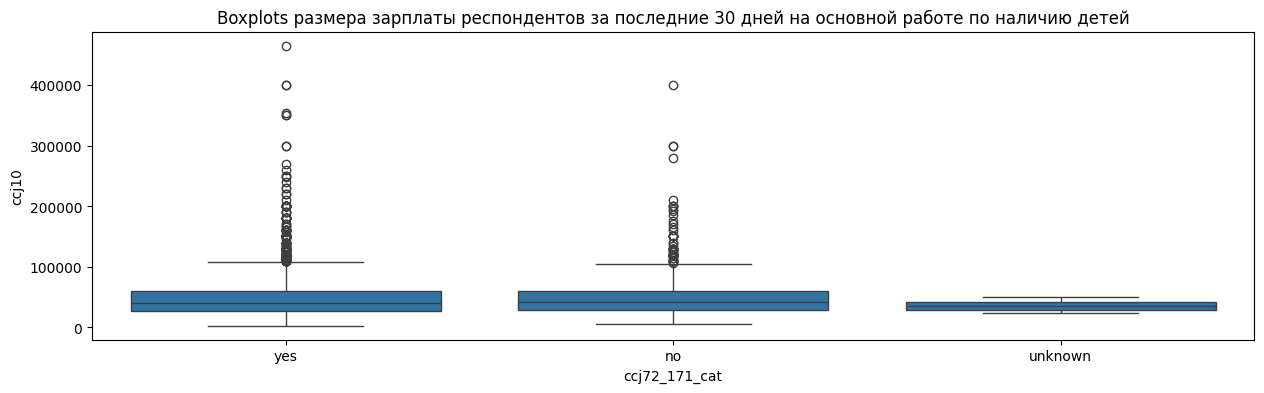

In [473]:
# Построим ящичковые диаграммы распределения зп по наличию детей
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj72_171_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по наличию детей')
plt.xlabel('ccj72_171_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Наличие детей". Переменная содержит 3 пропуска (категория "unknown"). В дальнейшем перед моделированием переменной применим OneHotEncoder для получения дамми.

##### **ccj72_172 (количество детей)**

In [474]:
# Заполним частично пропуски нулем
df.loc[df['ccj72_171_cat'] == 'no', 'ccj72_172'] = 0
# Заполним оставшиеся пропуски
df.loc[df['ccj72_172'].isnull()==True, 'ccj72_172'] = 'unknown'
df.loc[df['ccj72_172'] == 99999997, 'ccj72_172'] = 'unknown'
df.loc[df['ccj72_172'] == 99999998, 'ccj72_172'] = 'unknown'
df.loc[df['ccj72_172'] == 99999999, 'ccj72_172'] = 'unknown'
# Выведим содержимое столбца ccj72_172
print(df['ccj72_172'].value_counts())

ccj72_172
2.00        1571
1.00        1552
0.00        1208
3.00         372
4.00          81
5.00          12
6.00           9
 unknown       4
7.00           4
11.00          1
10.00          1
9.00           1
Name: count, dtype: int64


In [475]:
# Проверка
df[df['ccj72_172'].isnull()==True].shape[0]

0

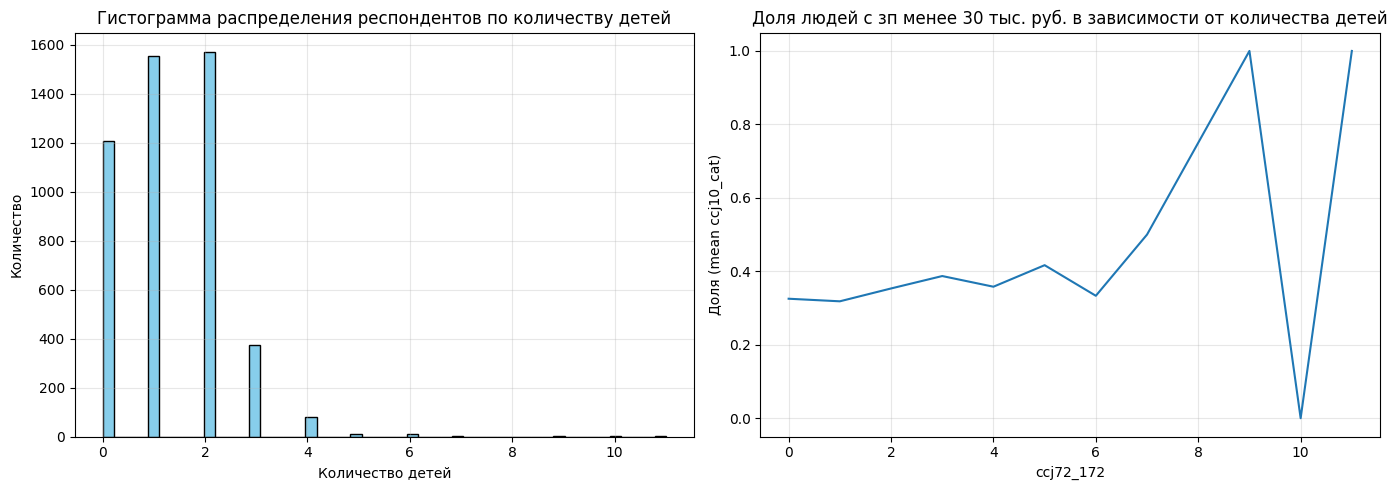

In [476]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj72_172'] != 'unknown']['ccj72_172'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по количеству детей')
axes[0].set_xlabel('Количество детей')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj72_172'] != 'unknown'].pivot_table(index='ccj72_172', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от количества детей')
axes[1].set_xlabel('ccj72_172')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj72_173 (количество детей моложе 18)**

In [477]:
# Заполним частично пропуски нулем
df.loc[df['ccj72_171_cat'] == 'no', 'ccj72_173'] = 0
# Заполним оставшиеся пропуски
df.loc[df['ccj72_173'].isnull()==True, 'ccj72_173'] = 'unknown'
df.loc[df['ccj72_173'] == 99999997, 'ccj72_173'] = 'unknown'
df.loc[df['ccj72_173'] == 99999998, 'ccj72_173'] = 'unknown'
df.loc[df['ccj72_173'] == 99999999, 'ccj72_173'] = 'unknown'
# Выведим содержимое столбца ccj72_173
print(df['ccj72_173'].value_counts())

ccj72_173
0.00        2873
1.00        1188
2.00         564
3.00         146
4.00          26
 unknown       7
5.00           5
6.00           5
8.00           1
10.00          1
Name: count, dtype: int64


In [478]:
# Проверка
df[df['ccj72_173'].isnull()==True].shape[0]

0

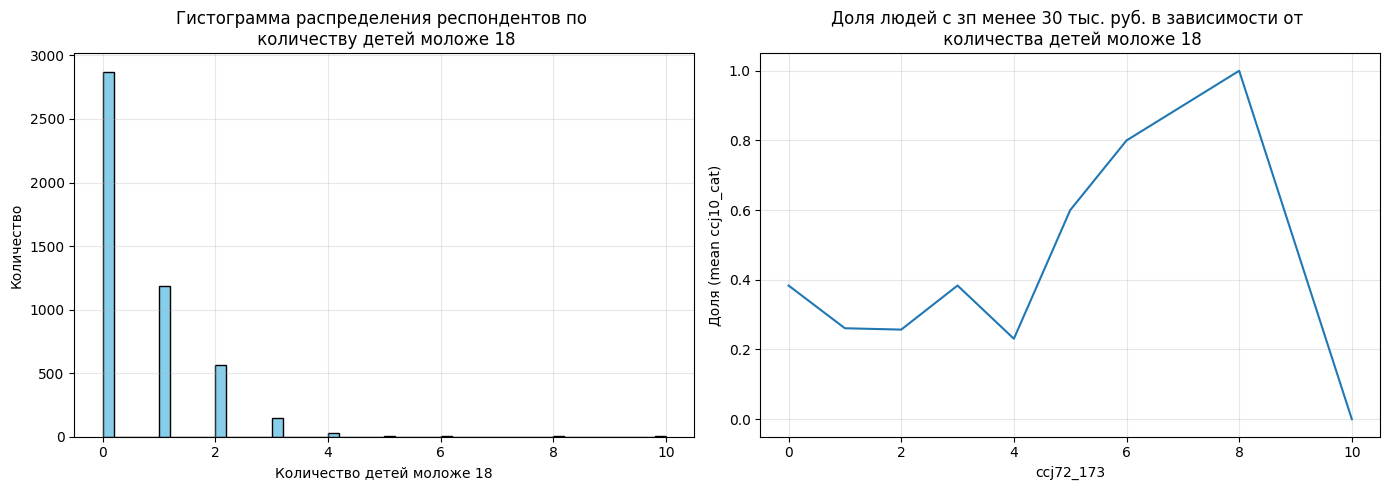

In [479]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj72_173'] != 'unknown']['ccj72_173'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n количеству детей моложе 18')
axes[0].set_xlabel('Количество детей моложе 18')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj72_173'] != 'unknown'].pivot_table(index='ccj72_173', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n количества детей моложе 18')
axes[1].set_xlabel('ccj72_173')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **cc_diplom (образование (группа))**  

In [480]:
# Заполним пропуски 'unknown'
df.loc[df['cc_diplom'].isnull()==True, 'cc_diplom'] = 'unknown'
df.loc[df['cc_diplom'] == 99999997, 'cc_diplom'] = 'unknown'
df.loc[df['cc_diplom'] == 99999998, 'cc_diplom'] = 'unknown'
df.loc[df['cc_diplom'] == 99999999, 'cc_diplom'] = 'unknown'
# Выведим содержимое столбца cc_diplom
print(df['cc_diplom'].value_counts())

cc_diplom
6.00        1665
5.00        1367
4.00        1351
3.00         337
2.00          72
 unknown      17
1.00           7
Name: count, dtype: int64


In [481]:
# Проверка
df[df['cc_diplom'].isnull()==True].shape[0]

0

In [482]:
# Категоризуем переменную cc_diplom на категории есть/нет высшее образование
df['cc_diplom_cat'] = df['cc_diplom'].map(cc_diplom_d_f)
# Заполним пропуски 'unknown'
df.loc[df['cc_diplom'] == 'unknown', 'cc_diplom_cat'] = 'unknown'
# Выведим содержимое столбца cc_diplom_cat
print(df['cc_diplom_cat'].value_counts())

cc_diplom_cat
no         3134
yes        1665
unknown      17
Name: count, dtype: int64


In [483]:
# Проверка
df[df['cc_diplom_cat'].isnull()==True].shape[0]

0

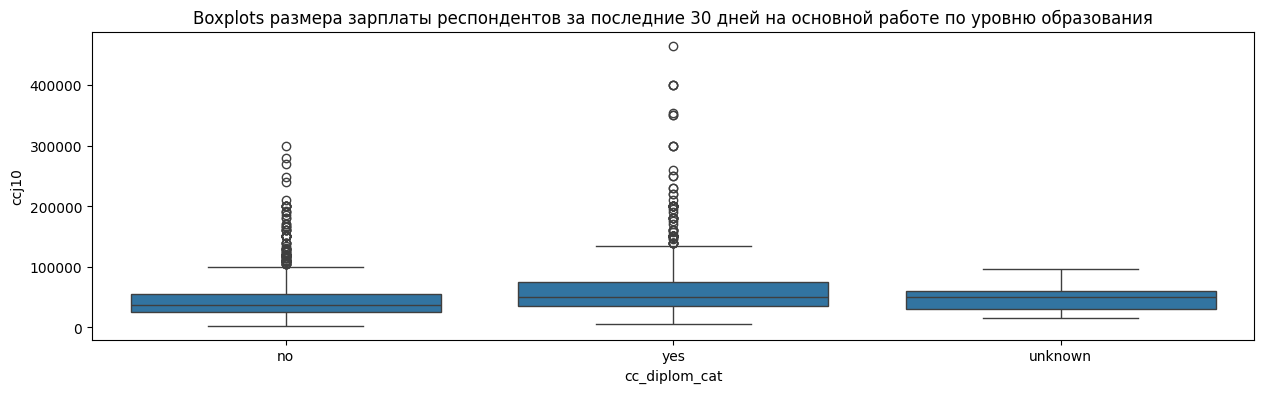

In [484]:
# Построим ящичковые диаграммы распределения зп по уровню образования
plt.figure(figsize=(15, 4))
sns.boxplot(x='cc_diplom_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по уровню образования')
plt.xlabel('cc_diplom_cat')
plt.ylabel('ccj10')
plt.show();

Предобработали переменную 'Образование (группа) "cc_diplom_cat". Переменная содержит 17 пропусков (категория "unknown"). В дальнейшем перед моделированием для cc_diplom_cat применим OneHotEncoder для получения дамми.  

In [485]:
# Категоризуем переменную cc_diplom по количеству лет образования
df['diplom_years'] = df['cc_diplom'].map(diplom_years_map)
# Удалим переменную cc_diplom
del df['cc_diplom']
# Заполним пропуски 'unknown'
df.loc[df['diplom_years'].isnull()==True, 'diplom_years'] = 'unknown'
# Выведим содержимое столбца diplom_years
print(df['diplom_years'].value_counts())

diplom_years
16         1665
13         1367
11         1351
9           337
8            72
unknown      17
6             7
Name: count, dtype: int64


In [486]:
# Проверка
df[df['diplom_years'].isnull()==True].shape[0]

0

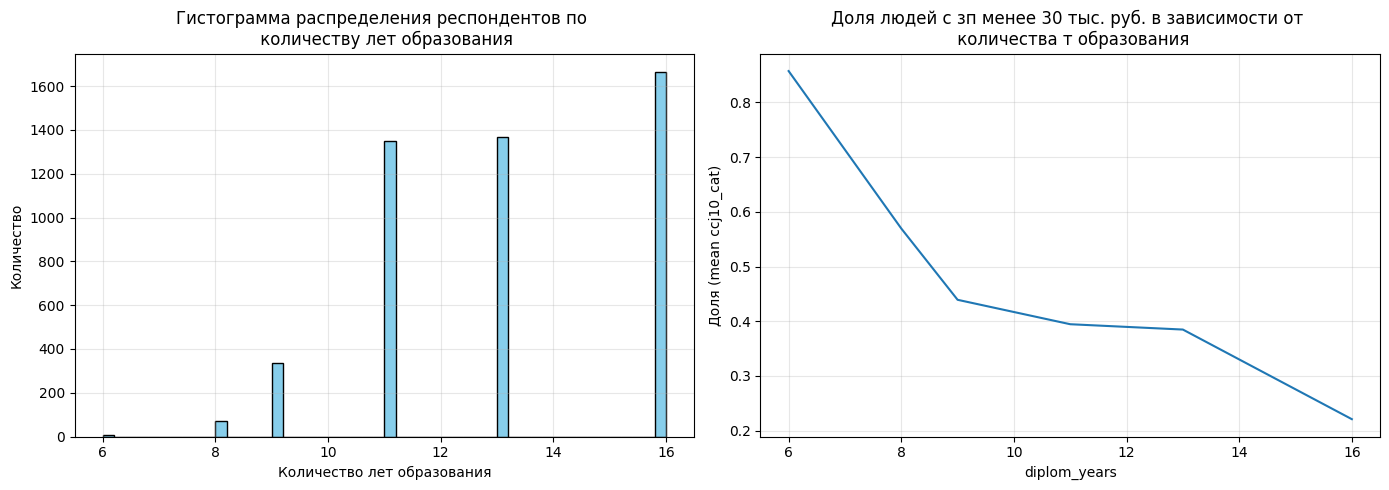

In [487]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['diplom_years'] != 'unknown']['diplom_years'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n количеству лет образования')
axes[0].set_xlabel('Количество лет образования')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['diplom_years'] != 'unknown'].pivot_table(index='diplom_years', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n количества т образования')
axes[1].set_xlabel('diplom_years')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj260_cat (владение иностранным языком)**  

In [488]:
# Категоризуем переменную ccj260
df['ccj260_cat'] = df['ccj260'].map(ccj260_d)
# Заполним пропуски 'unknown'
df.loc[df['ccj260'].isnull()==True, 'ccj260_cat'] = 'no'
# Удалим переменную ccj260
del df['ccj260']
# Выведим содержимое столбца ccj260_cat
print(df['ccj260_cat'].value_counts())

ccj260_cat
no         3854
yes         924
unknown      38
Name: count, dtype: int64


In [489]:
# Проверка
df[df['ccj260_cat'].isnull()==True].shape[0]

0

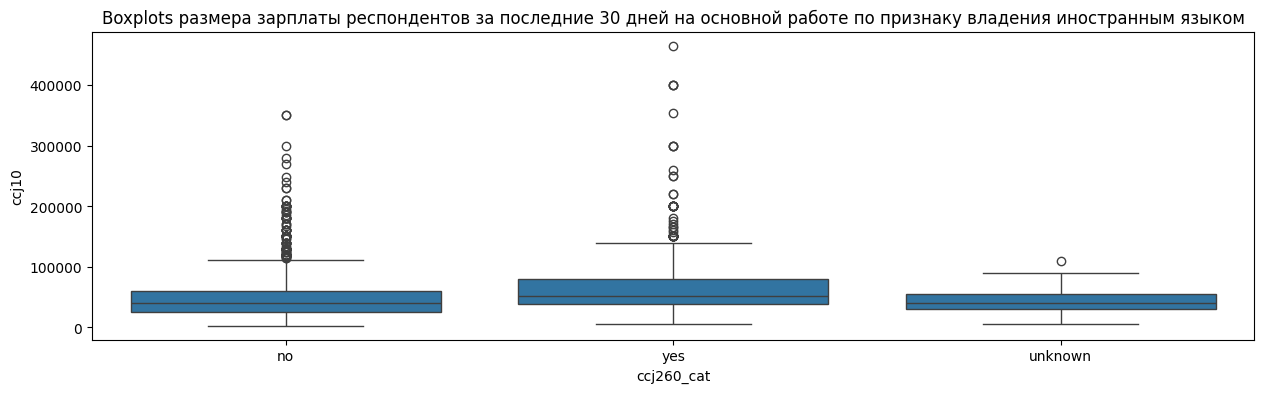

In [490]:
# Построим ящичковые диаграммы распределения зп по владению иностранным языком
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj260_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по признаку владения иностранным языком')
plt.xlabel('ccj260_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Владение иностранным языком". Переменная содержит 38 пропусков (категория "unknown"). В дальнейшем перед моделированием переменной применим OneHotEncoder для получения дамми.

##### **ccj262 (степень владение иностранным языком)**

In [491]:
# Заполним пропуски 'unknown'
df.loc[df['ccj260_cat'] == 'no', 'ccj262'] = 4
df.loc[df['ccj262'].isnull()==True, 'ccj262'] = 'unknown'
df.loc[df['ccj262'] == 99999997, 'ccj262'] = 'unknown'
df.loc[df['ccj262'] == 99999998, 'ccj262'] = 'unknown'
df.loc[df['ccj262'] == 99999999, 'ccj262'] = 'unknown'
print(df['ccj262'].value_counts())

ccj262
4.00        3854
3.00         636
2.00         227
1.00          59
 unknown      40
Name: count, dtype: int64


In [492]:
# Проверка
df[df['ccj262'].isnull()==True].shape[0]

0

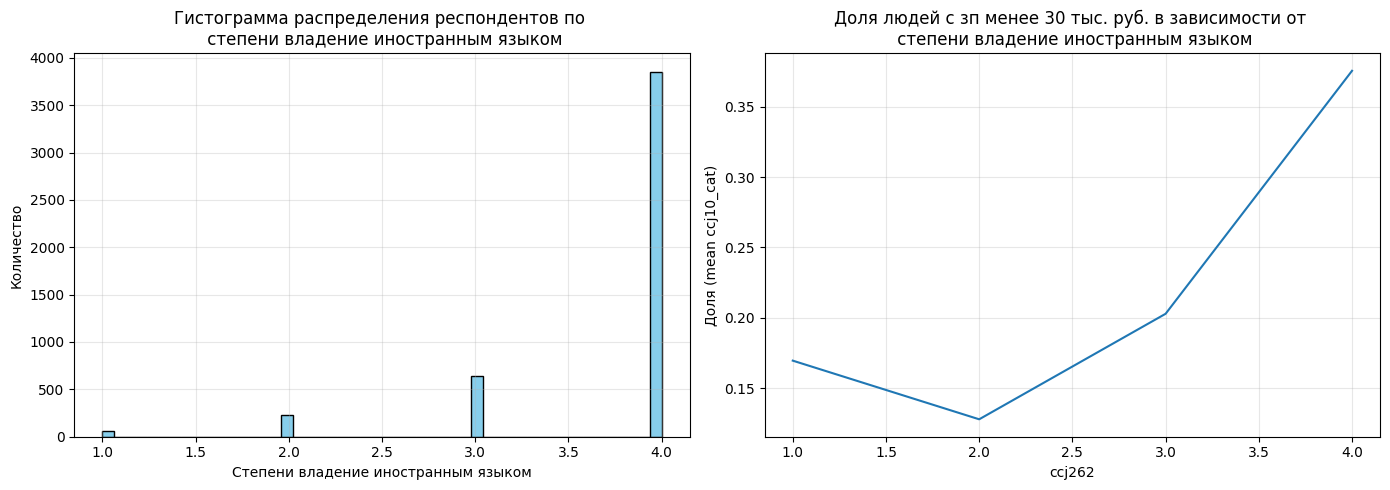

In [493]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj262'] != 'unknown']['ccj262'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n степени владение иностранным языком')
axes[0].set_xlabel('Степени владение иностранным языком')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj262'] != 'unknown'].pivot_table(index='ccj262', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n степени владение иностранным языком')
axes[1].set_xlabel('ccj262')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj161_3y (стаж, лет) и ccj161_3m (стаж месяцев)**

In [494]:
# Заполним пропуски 'unknown' для 'cj161_3y'
df.loc[df['ccj161_3y'].isnull()==True, 'ccj161_3y'] = 'unknown'
df.loc[df['ccj161_3y'] == 99999996, 'ccj161_3y'] = 0
df.loc[df['ccj161_3y'] == 99999997, 'ccj161_3y'] = 'unknown'
df.loc[df['ccj161_3y'] == 99999998, 'ccj161_3y'] = 'unknown'
df.loc[df['ccj161_3y'] == 99999999, 'ccj161_3y'] = 'unknown'

In [495]:
# Проверка
df[df['ccj161_3y'].isnull()==True].shape[0]

0

In [496]:
# Проверка
df[df['ccj161_3y']=='unknown'].shape[0]

283

In [497]:
# Заполним пропуски 'unknown' для 'ccj161_3m'
df.loc[df['ccj161_3m'].isnull()==True, 'ccj161_3m'] = 'unknown'
df.loc[df['ccj161_3m'] == 99999997, 'ccj161_3m'] = 'unknown'
df.loc[df['ccj161_3m'] == 99999998, 'ccj161_3m'] = 'unknown'
df.loc[df['ccj161_3m'] == 99999999, 'ccj161_3m'] = 'unknown'

In [498]:
# Проверка
df[df['ccj161_3m'].isnull()==True].shape[0]

0

In [499]:
# Проверка
df[df['ccj161_3m']=='unknown'].shape[0]

381

In [500]:
# Вычислим стаж всего в годах
def calc_exp(row):
    """Функция вычисляет стаж всего в годах"""
    if row['ccj161_3m'] == 'unknown':
        return row['ccj161_3y']
    else:
        return int(row['ccj161_3m'])/12 + int(row['ccj161_3y'])
# Создадим категоризованный столбец cc_age_cat
df['exp']  = df.apply(calc_exp, axis=1)

In [501]:
# Проверка
df[df['exp'].isnull()==True].shape[0]

0

In [502]:
# Проверка
df[df['exp']=='unknown'].shape[0]

283

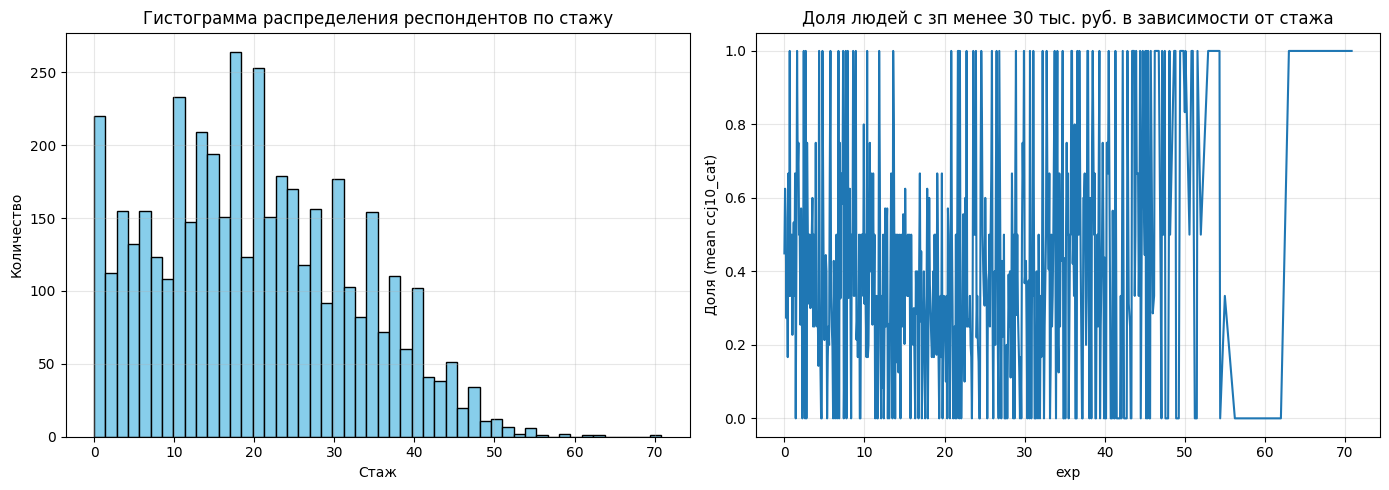

In [503]:
# Удалим столбцы
del df['ccj161_3y']
del df['ccj161_3m']

# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['exp'] != 'unknown']['exp'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по стажу')
axes[0].set_xlabel('Стаж')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['exp'] != 'unknown'].pivot_table(index='exp', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от стажа')
axes[1].set_xlabel('exp')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj5a - (стаж на текущем месте работы (лет)) и ccj5b (стаж на текущем месте работы (мес))**

In [504]:
# Заполним пропуски 'unknown' для 'ccj5a'
df.loc[df['ccj5a'].isnull()==True, 'ccj5a'] = 'unknown'
df.loc[df['ccj5a'] == 99999997, 'ccj5a'] = 'unknown'
df.loc[df['ccj5a'] == 99999998, 'ccj5a'] = 'unknown'
df.loc[df['ccj5a'] == 99999999, 'ccj5a'] = 'unknown'

In [505]:
# Проверка
df[df['ccj5a'].isnull()==True].shape[0]

0

In [506]:
# Проверка
df[df['ccj5a']=='unknown'].shape[0]

31

In [507]:
# Заполним пропуски 'unknown' для 'ccj5b'
df.loc[df['ccj5b'].isnull()==True, 'ccj5b'] = 'unknown'
df.loc[df['ccj5b'] == 99999997, 'ccj5b'] = 'unknown'
df.loc[df['ccj5b'] == 99999998, 'ccj5b'] = 'unknown'
df.loc[df['ccj5b'] == 99999999, 'ccj5b'] = 'unknown'

In [508]:
# Проверка
df[df['ccj5b'].isnull()==True].shape[0]

0

In [509]:
# Проверка
df[df['ccj5b']=='unknown'].shape[0]

203

In [510]:
# Вычислим стаж на текущем месте работы в годах
def calc_exp_cur(row):
    """Функция вычисляет стаж всего в годах на текущем месте работы"""
    if (row['ccj5b'] == 'unknown') and (row['ccj5a'] == 'unknown'):
        return 'unknown'
    elif (row['ccj5b'] != 'unknown') and (row['ccj5a'] == 'unknown'):
        return row['ccj5b']/12
    elif (row['ccj5b'] == 'unknown') and (row['ccj5a'] != 'unknown'):
        return int(row['cc_int_y']) - int(row['ccj5a'])
    else:
        return int(row['ccj5b'])/12 + (int(row['cc_int_y']) - int(row['ccj5a']))
# Создадим категоризованный столбец
df['exp_curr']  = df.apply(calc_exp_cur, axis=1)

In [511]:
# Проверка
df[df['exp_curr'].isnull()==True].shape[0]

0

In [512]:
# Проверка
df[df['exp_curr']=='unknown'].shape[0]

27

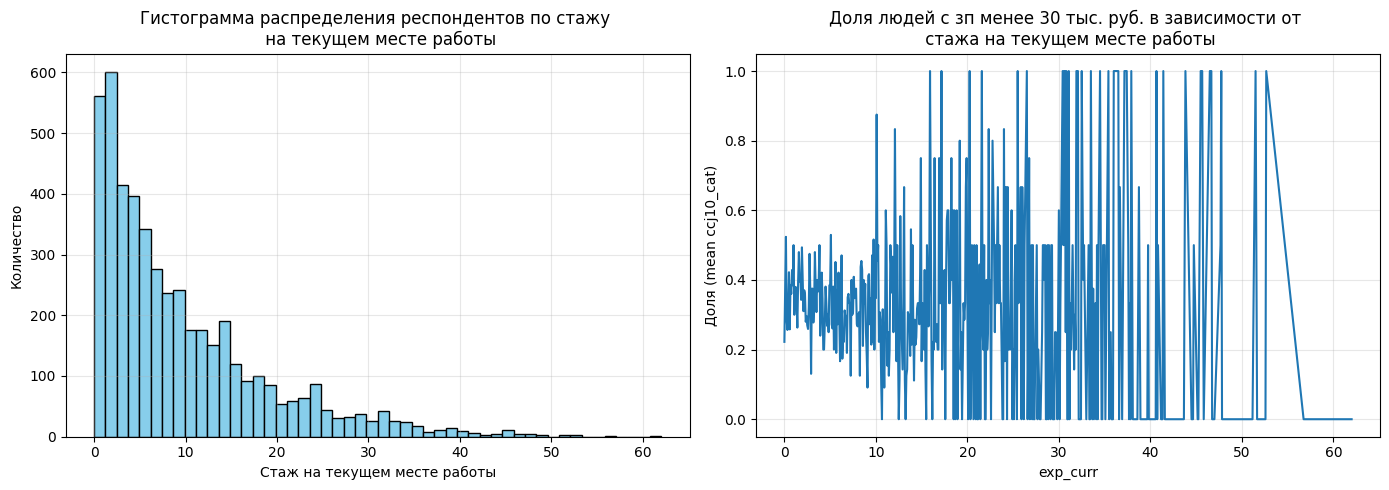

In [513]:
# Удалим столбцы
del df['ccj5a']
del df['ccj5b']
del df['cc_int_y']

# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['exp_curr'] != 'unknown']['exp_curr'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по стажу \n на текущем месте работы')
axes[0].set_xlabel('Стаж на текущем месте работы')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['exp_curr'] != 'unknown'].pivot_table(index='exp_curr', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n стажа на текущем месте работы')
axes[1].set_xlabel('exp_curr')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj6_2 (продолжительность рабочей недели в часах)**

In [514]:
# Заполним пропуски 'unknown'
df.loc[df['ccj6_2'].isnull()==True, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999996, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999997, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999998, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999999, 'ccj6_2'] = 'unknown'

In [515]:
# Проверка
df[df['ccj6_2'].isnull()==True].shape[0]

0

In [516]:
# Проверка
df[df['ccj6_2']=='unknown'].shape[0]

518

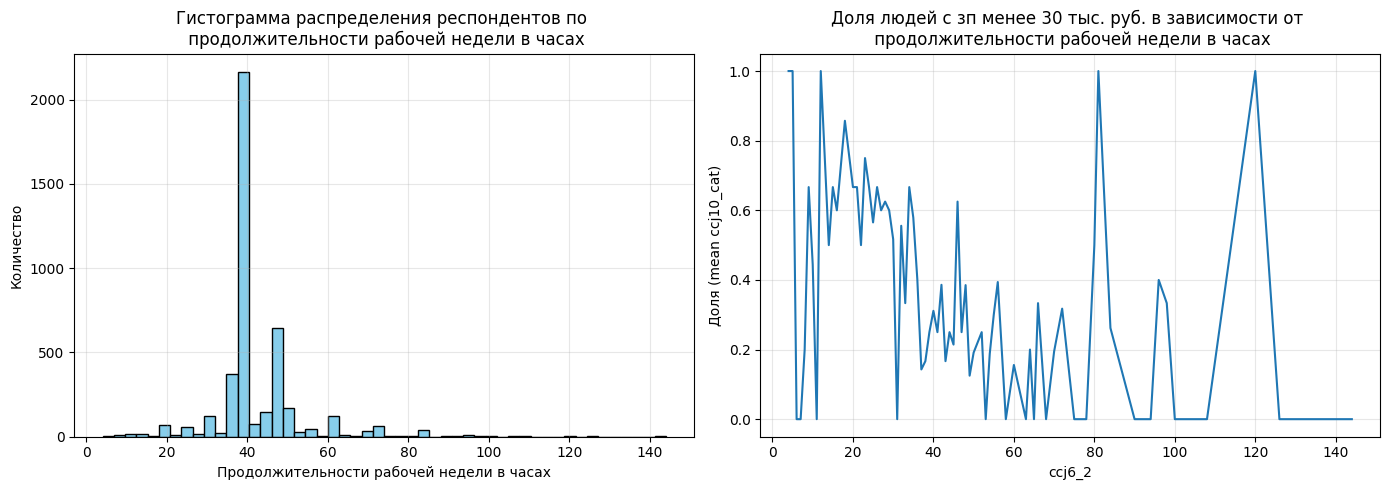

In [517]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj6_2'] != 'unknown']['ccj6_2'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n продолжительности рабочей недели в часах')
axes[0].set_xlabel('Продолжительности рабочей недели в часах')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj6_2'] != 'unknown'].pivot_table(index='ccj6_2', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n продолжительности рабочей недели в часах')
axes[1].set_xlabel('ccj6_2')
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **region (регион) & status (тип населенного пункта)**

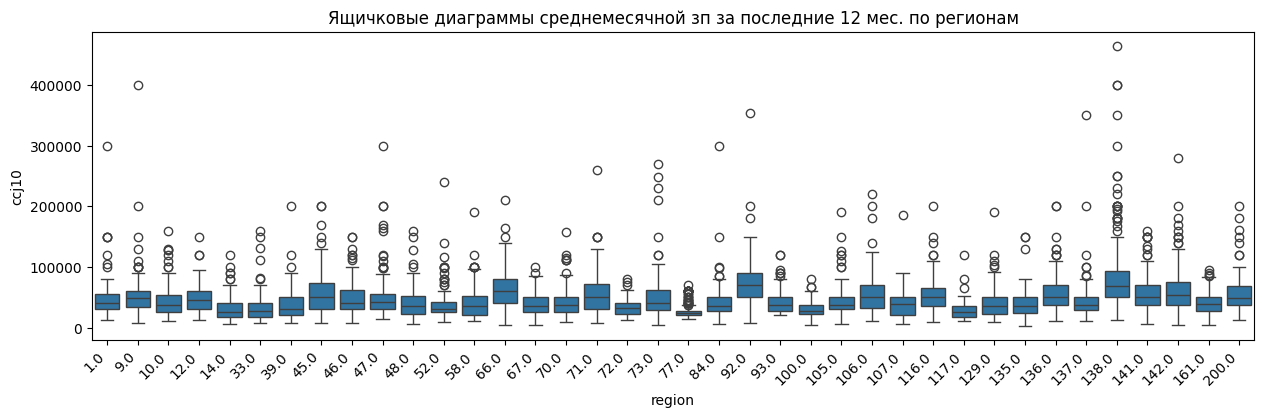

In [518]:
# Построим ящичковые диаграммы распределения зп по регионам
plt.figure(figsize=(15, 4))
sns.boxplot(x='region', y='ccj10', data=df, orientation='vertical')
plt.title('Ящичковые диаграммы среднемесячной зп за последние 12 мес. по регионам')
plt.xlabel('region')
plt.xticks(rotation=45, ha='right')
plt.ylabel('ccj10')
plt.show();

Видим, что медианый доход очень высокий в регионах 66 (Красноярск), 92 (Владивосток), 138 (Москва).

In [519]:
# Категоризуем переменную status
df['status_cat'] = df['status'].map(status_d)
# Удалим переменную status
del df['status']
# Выведим содержимое столбца status
print(df['status_cat'].value_counts())

status_cat
center_area      2120
city             1302
village           982
urban_village     412
Name: count, dtype: int64


In [520]:
# Проверка
df[df['status_cat'].isnull()==True].shape[0]

0

In [521]:
# Посмотрим, какие регионы попали в center_area
df[df['status_cat']=='center_area']['region'].unique()

array([  9.,  45.,  46.,  66.,  70.,  71.,  72.,  92., 105., 106., 116.,
       135., 136., 138., 141.])

Видим, что 66 (Красноярск), 92 (Владивосток), 138 (Москва) входят в 'center_area'. В категории 'center_area' выделим подгатегорию (Красноярск, Владивосток, Москва).

In [522]:
# Категоризуем переменную status
df['status_cat'] = np.where(df['region'].isin([66, 92, 138]), 'center_area_high', df['status_cat'])
# Удалим переменную "region"
del df['region']
# Выведим содержимое столбца status
print(df['status_cat'].value_counts())

status_cat
center_area         1494
city                1297
village              975
center_area_high     638
urban_village        412
Name: count, dtype: int64


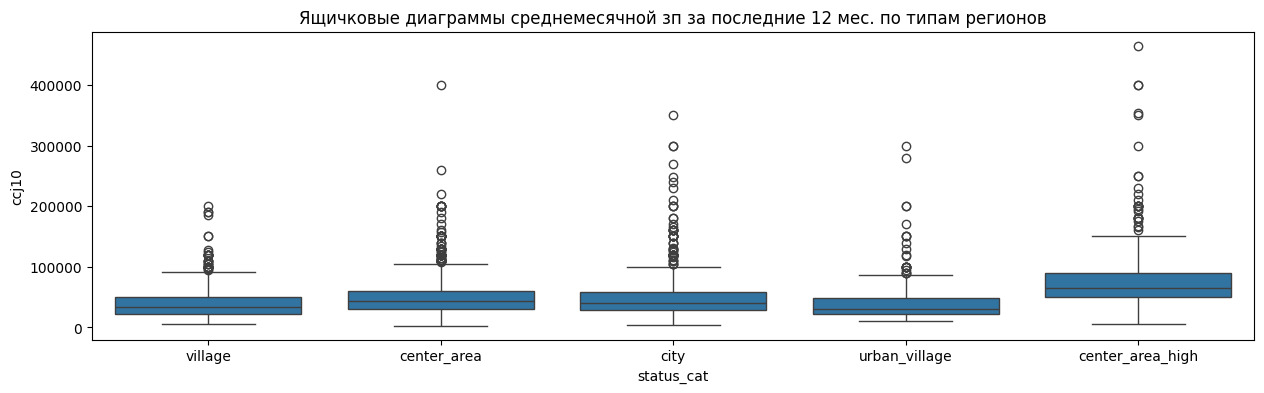

In [523]:
# Построим ящичковые диаграммы распределения зп по типам регионов
plt.figure(figsize=(15, 4))
sns.boxplot(x='status_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Ящичковые диаграммы среднемесячной зп за последние 12 мес. по типам регионов')
plt.xlabel('status_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Тип населенного пункта". Переменная не содержит пропусков. В дальнейшем перед моделированием применим OneHotEncoder для получения дамми.

##### **cc_occup08 (профессиональная группа)**

In [524]:
# Заполним пропуски 'unknown'
df.loc[df['cc_occup08'].isnull()==True, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999997, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999998, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999999, 'cc_occup08'] = 'unknown'
# Выведим содержимое столбца cc_occup08
print(df['cc_occup08'].value_counts())

cc_occup08
3.00        941
5.00        889
2.00        848
7.00        618
8.00        581
9.00        371
4.00        270
1.00        254
0.00         24
 unknown     13
6.00          7
Name: count, dtype: int64


In [525]:
# Проверка
df[df['cc_occup08'].isnull()==True].shape[0]

0

Переменная содержит пропуски.

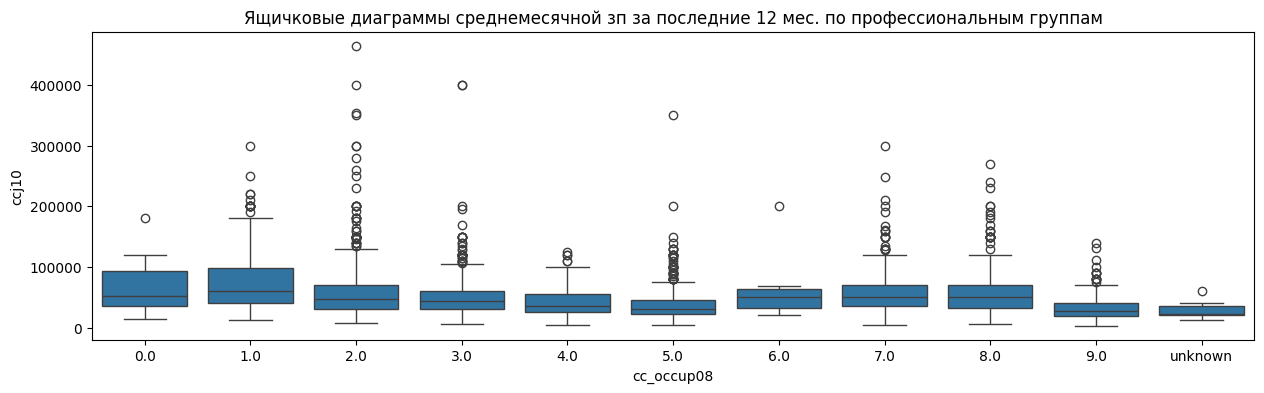

In [526]:
# Зададим порядок
order = ['0.0','1.0','2.0','3.0','4.0','5.0','6.0','7.0','8.0','9.0','unknown']
# Построим ящичковые диаграммы распределения зп по профессиональным группам
plt.figure(figsize=(15, 4))
sns.boxplot(x='cc_occup08', y='ccj10', data=df, orientation='vertical', order = order)
plt.title('Ящичковые диаграммы среднемесячной зп за последние 12 мес. по профессиональным группам')
plt.xlabel('cc_occup08')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Профессиональная группа". Переменная содержит 13 пропусков. В дальнейшем перед моделированием переменной применим OneHotEncoder.

##### **ccj4_1 (отрасль)**

In [527]:
# Заполним пропуски 'unknown'
df.loc[df['ccj4_1'].isnull()==True, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999997, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999998, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999999, 'ccj4_1'] = 'unknown'
# Выведим содержимое столбца ccj4_1
print(df['ccj4_1'].value_counts())

ccj4_1
14.00       1065
10.00        479
7.00         439
12.00        433
6.00         308
1.00         273
13.00        213
17.00        201
5.00         190
8.00         170
3.00         145
11.00        120
9.00         120
2.00          97
16.00         90
15.00         89
27.00         77
4.00          77
20.00         36
 unknown      29
24.00         27
23.00         24
25.00         24
26.00         20
18.00         19
21.00         17
30.00         16
29.00          7
28.00          6
31.00          4
22.00          1
Name: count, dtype: int64


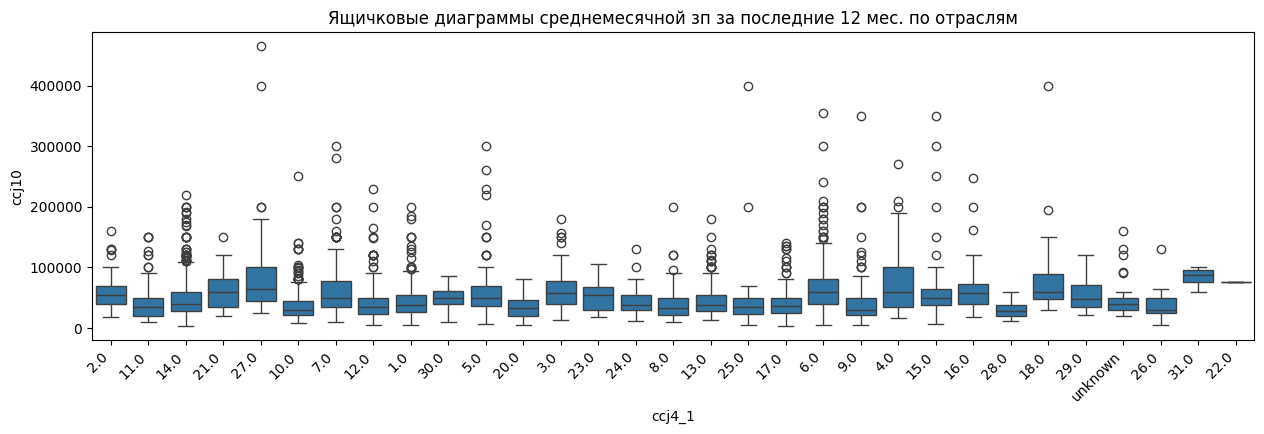

In [528]:
# Построим ящичковые диаграммы распределения зп по отраслям
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj4_1', y='ccj10', data=df, orientation='vertical')
plt.title('Ящичковые диаграммы среднемесячной зп за последние 12 мес. по отраслям')
plt.xlabel('ccj4_1')
plt.xticks(rotation=45, ha='right')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Отрасль". Переменная содержит 29 пропусков. В дальнейшем перед моделированием переменной применим OneHotEncoder.

##### **ccj6 (наличие подчиненных)**

In [529]:
# Категоризуем итогово переменную ccj6
df['ccj6_cat'] = df['ccj6'].map(ccj6_d)
# Заполним пропуски
df.loc[df['ccj6'].isnull()==True, 'ccj6_cat'] = 'unknown'
# Удалим переменную ccj6
del df['ccj6']
# Выведим содержимое столбца ccj6_cat
print(df['ccj6_cat'].value_counts())

ccj6_cat
no         4004
yes         804
unknown       8
Name: count, dtype: int64


In [530]:
# Проверка
df[df['ccj6_cat'].isnull()==True].shape[0]

0

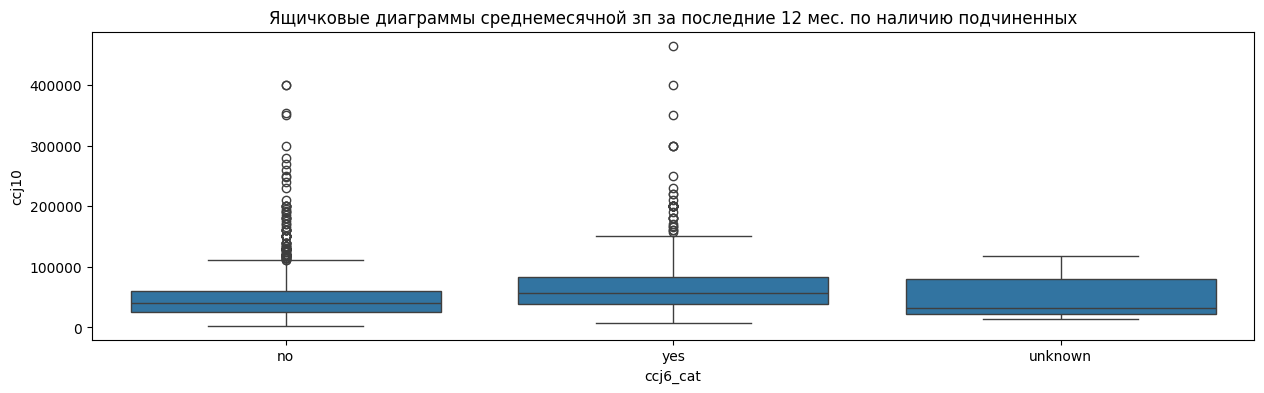

In [531]:
# Построим ящичковые диаграммы распределения зп по наличию подчиненных
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj6_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Ящичковые диаграммы среднемесячной зп за последние 12 мес. по наличию подчиненных')
plt.xlabel('ccj6_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Наличие подчиненных". Переменная содержит 8 пропусков.  В дальнейшем перед моделированием переменной применим OneHotEncoder.


##### **ccj6_0 (количество подчиненных)**

In [532]:
# Заполним пропуски 'unknown'
df.loc[df['ccj6_cat']=='no', 'ccj6_0'] = 0
df.loc[df['ccj6_0'].isnull()==True, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999997, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999998, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999999, 'ccj6_0'] = 'unknown'
# Выведим содержимое столбца ccj6_cat
print(df['ccj6_0'].value_counts())

ccj6_0
0.00        4004
2.00         103
3.00          82
5.00          82
1.00          81
4.00          67
10.00         58
6.00          55
15.00         36
8.00          29
20.00         22
7.00          20
12.00         20
 unknown      19
30.00         18
40.00         17
9.00          13
25.00          8
18.00          8
14.00          6
50.00          6
16.00          5
11.00          4
60.00          4
24.00          3
17.00          3
100.00         3
45.00          3
19.00          2
21.00          2
23.00          2
49.00          2
35.00          2
37.00          2
28.00          2
150.00         2
200.00         2
22.00          1
300.00         1
36.00          1
56.00          1
90.00          1
1,218.00       1
31.00          1
26.00          1
58.00          1
130.00         1
27.00          1
13.00          1
210.00         1
32.00          1
54.00          1
116.00         1
52.00          1
900.00         1
34.00          1
Name: count, dtype: int64


In [533]:
# Проверка
df[df['ccj6_0'].isnull()==True].shape[0]

0

In [534]:
# Проверка
df[df['ccj6_0']=='unknown'].shape[0]

19

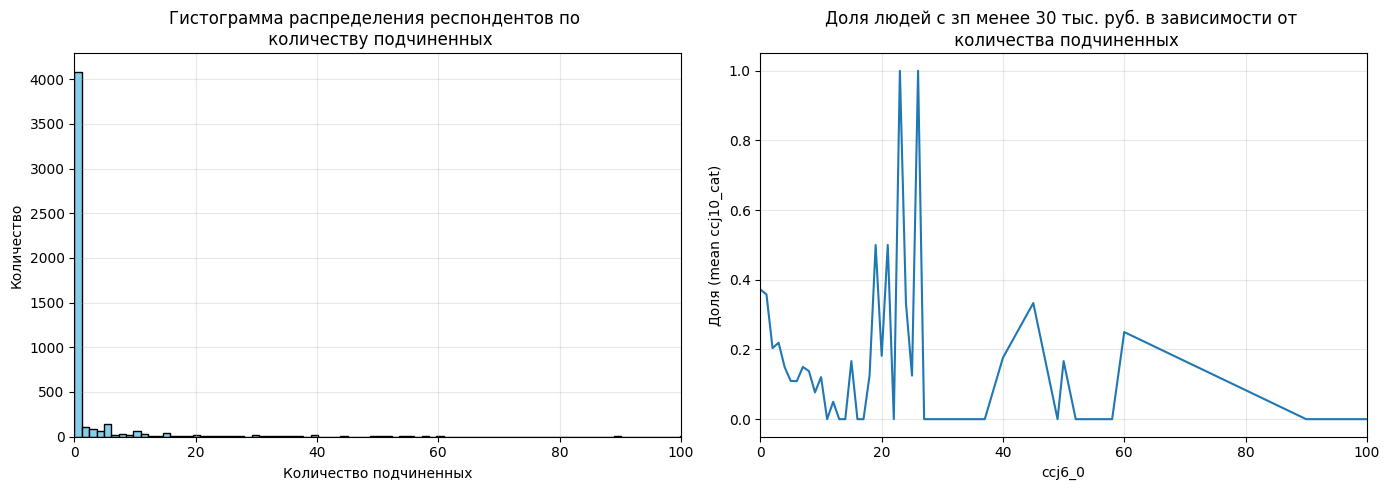

In [535]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj6_0'] != 'unknown']['ccj6_0'], bins=1000, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n количеству подчиненных')
axes[0].set_xlabel('Количество подчиненных')
axes[0].set_xlim(0, 100)
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj6_0'] != 'unknown'].pivot_table(index='ccj6_0', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n количества подчиненных')
axes[1].set_xlabel('ccj6_0')
axes[1].set_xlim(0, 100)
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj11 (тип занятости)**

In [536]:
# Категоризуем итогово переменную ccj11
df['ccj11_cat'] = df['ccj11'].map(ccj11_d)
# Заполним пропуски
df.loc[df['ccj11'].isnull()==True, 'ccj11_cat'] = 'unknown'
# Удалим переменную ccj11
del df['ccj11']
# Выведим содержимое столбца ccj11
print(df['ccj11_cat'].value_counts())

ccj11_cat
enterprise        4257
not_enterprise     359
self_employed      105
individual          89
unknown              6
Name: count, dtype: int64


In [537]:
# Проверка
df[df['ccj11_cat'].isnull()==True].shape[0]

0

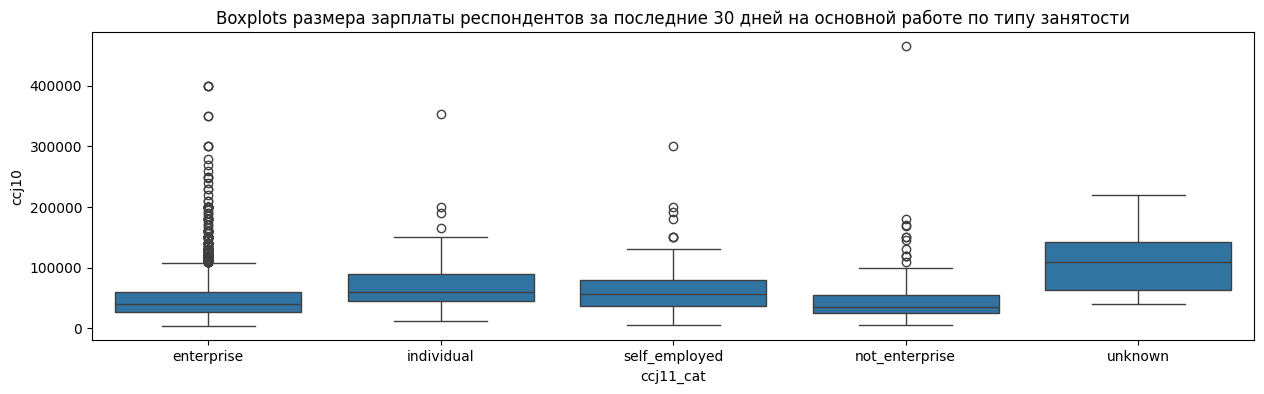

In [538]:
# Построим ящичковые диаграммы распределения зп по типу занятости
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj11_cat', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по типу занятости')
plt.xlabel('ccj11_cat')
plt.ylabel('ccj10')
plt.show();

Категоризовали переменную "Тип занятости". Переменная содержит 6 пропусков. В дальнейшем перед моделированием переменной применим OneHotEncoder.

##### **ccj13 (численность сотрудников)**

In [539]:
# Заполним пропуски 'unknown'
df.loc[df['ccj13'].isnull()==True, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999997, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999998, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999999, 'ccj13'] = 'unknown'
# Выведим содержимое столбца ccj13
print(df['ccj13'].value_counts())

ccj13
 unknown      1626
97.00          225
30.00          179
20.00          172
50.00          155
              ... 
1,050.00         1
88.00            1
290.00           1
300,000.00       1
100,000.00       1
Name: count, Length: 190, dtype: int64


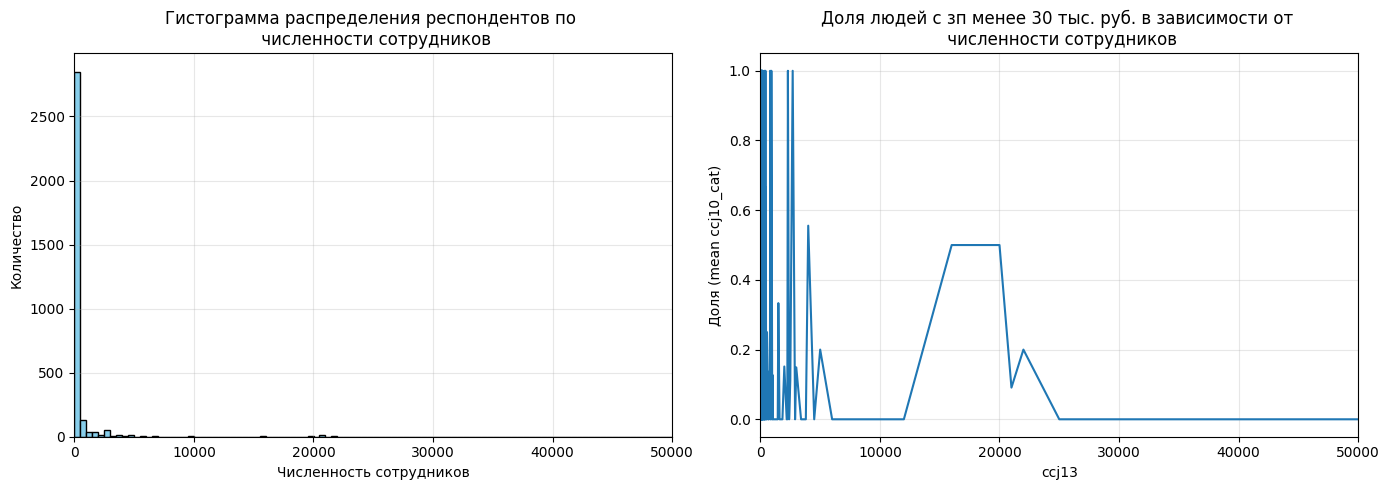

In [540]:
# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist(df[df['ccj13'] != 'unknown']['ccj13'], bins=1000, edgecolor='black', color='skyblue')
axes[0].set_title('Гистограмма распределения респондентов по \n численности сотрудников')
axes[0].set_xlabel('Численность сотрудников')
axes[0].set_xlim(0, 50000)
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

pivot = df[df['ccj13'] != 'unknown'].pivot_table(index='ccj13', values='ccj10_cat', aggfunc='mean')
pivot.plot(ax=axes[1], legend=False)
axes[1].set_title('Доля людей с зп менее 30 тыс. руб. в зависимости от \n численности сотрудников')
axes[1].set_xlabel('ccj13')
axes[1].set_xlim(0, 50000)
axes[1].set_ylabel('Доля (mean ccj10_cat)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### **ccj23 (госучастие)**

In [541]:
# Заполним пропуски 'unknown'
df.loc[df['ccj23'].isnull()==True, 'ccj23'] = 'unknown'
df.loc[df['ccj23'] == 99999997, 'ccj23'] = 'unknown'
df.loc[df['ccj23'] == 99999998, 'ccj23'] = 'unknown'
df.loc[df['ccj23'] == 99999999, 'ccj23'] = 'unknown'
# Категоризуем
df.loc[df['ccj23'] == 1, 'ccj23'] = 'yes'
df.loc[df['ccj23'] == 2, 'ccj23'] = 'no'
# Выведим содержимое столбца ccj23
print(df['ccj23'].value_counts())

ccj23
no         2264
yes        1831
unknown     721
Name: count, dtype: int64


In [542]:
# Проверка
df[df['ccj23'].isnull()==True].shape[0]

0

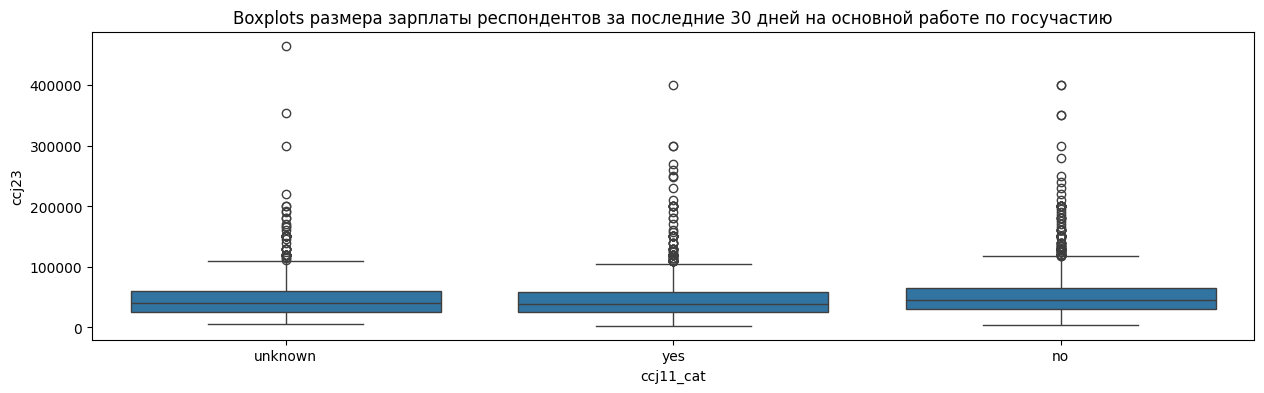

In [543]:
# Построим ящичковые диаграммы распределения зп по госучастию
plt.figure(figsize=(15, 4))
sns.boxplot(x='ccj23', y='ccj10', data=df, orientation='vertical')
plt.title('Boxplots размера зарплаты респондентов за последние 30 дней на основной работе по госучастию')
plt.xlabel('ccj11_cat')
plt.ylabel('ccj23')
plt.show();

Категоризовали переменную "Госучастие". Переменная содержит 721 пропуск. В дальнейшем перед моделированием переменной применим OneHotEncoder.

##### **Итоги изучения и предобработки фичей**

In [544]:
# Удалим столбцы
del df['ccid_i'] # id
del df['ccj10'] # не категоризированный таргет
# Выведим первые 5 строк датафрейма
df.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,cc_occup08,ccj4_1,ccj6_0,ccj13,ccj23,ccj10_cat,cch5_cat,cc_marst_cat,ccj72_171_cat,cc_diplom_cat,diplom_years,ccj260_cat,exp,exp_curr,status_cat,ccj6_cat,ccj11_cat
3,61.00,3.00,0.00,4.00,unknown,5.00,2.00,0.00,150.00,unknown,1,female,married,yes,no,11,no,42.00,1.92,village,no,enterprise
4,55.50,3.00,0.00,4.00,45.00,5.00,2.00,0.00,unknown,yes,0,male,married,yes,no,11,no,35.00,0.58,village,no,enterprise
9,37.50,1.00,1.00,3.00,40.00,3.00,11.00,0.00,20.00,yes,0,female,married,yes,yes,16,yes,18.00,1.42,center_area,no,enterprise
12,59.50,2.00,0.00,4.00,40.00,5.00,14.00,0.00,unknown,unknown,0,female,not_married,yes,no,13,no,33.00,33.75,center_area,no,individual
13,42.50,0.00,0.00,3.00,40.00,2.00,21.00,0.00,unknown,unknown,0,male,not_married,no,yes,16,yes,14.00,2.58,center_area,no,self_employed


In [545]:
# Удаление пропусков
df = df[df['cc_marst_cat']!='unknown']
df = df[df['ccj72_171_cat']!='unknown']
df = df[df['ccj72_172']!='unknown']
df = df[df['ccj72_173']!='unknown']
df = df[df['cc_diplom_cat']!='unknown']
df = df[df['diplom_years']!='unknown']
df = df[df['ccj260_cat']!='unknown']
df = df[df['ccj262']!='unknown']
df = df[df['exp']!='unknown']
df = df[df['exp_curr']!='unknown']
df = df[df['cc_occup08']!='unknown']
df = df[df['ccj6_2']!='unknown']
df = df[df['ccj4_1']!='unknown']
df = df[df['ccj6_cat']!='unknown']
df = df[df['ccj6_0']!='unknown']
df = df[df['ccj11_cat']!='unknown']
df = df[df['ccj13']!='unknown']
df = df[df['ccj23']!='unknown']
# Доп фильтрация по возрасту
df = df[df['cc_age'] < 60]
# Приведение типов
df['ccj72_172'] = df['ccj72_172'].astype('float')
df['ccj72_173'] = df['ccj72_173'].astype('float')
df['diplom_years'] = df['diplom_years'].astype('int')
df['ccj262'] = df['ccj262'].astype('int')
df['exp'] = df['exp'].astype('int')
df['exp_curr'] = df['exp_curr'].astype('int')
df['ccj6_2'] = df['ccj6_2'].astype('int')
df['ccj6_0'] = df['ccj6_0'].astype('int')
df['ccj13'] = df['ccj13'].astype('int')
# Выведим общую информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2442 entries, 9 to 11997
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cc_age         2442 non-null   float64
 1   ccj72_172      2442 non-null   float64
 2   ccj72_173      2442 non-null   float64
 3   ccj262         2442 non-null   int64  
 4   ccj6_2         2442 non-null   int64  
 5   cc_occup08     2442 non-null   object 
 6   ccj4_1         2442 non-null   object 
 7   ccj6_0         2442 non-null   int64  
 8   ccj13          2442 non-null   int64  
 9   ccj23          2442 non-null   object 
 10  ccj10_cat      2442 non-null   int64  
 11  cch5_cat       2442 non-null   object 
 12  cc_marst_cat   2442 non-null   object 
 13  ccj72_171_cat  2442 non-null   object 
 14  cc_diplom_cat  2442 non-null   object 
 15  diplom_years   2442 non-null   int64  
 16  ccj260_cat     2442 non-null   object 
 17  exp            2442 non-null   int64  
 18  exp_curr    

Итак, первоначально датасет содержал  данные о 12 тыс респондентов. Поскольку цель - построить модель прогноза заработной платы за последние 30 дней, то из датасета были удалены:
 - не имеющие работу (ccj77==1),
 - инвалиды (ccm20_7==2)),
 - ученики, пенсионеры, студенты, ... (ccj90>=10&ccj90<=13),
 - ненадежные ответы респондентов (ccs7==1),
 - не указавшие размер заработной платы за последние 30 дней (ccj10!=unknown),
 - респонденты в возрасте 60 и более лет (cc_age<60),
 - пропуски по фичам:

|Фичи|Пропуски|Трансформация|
|------|------|------|
|cch5_cat (Пол респондента)|Нет|OHE|
|cc_age (Возраст респондента)|Нет|Нет|
|cc_marst_cat (Семейное положение)|Есть (категория 'unknown'-14)|OHE|
|ccj72_171_cat (есть ли дети)|Есть (категория 'unknown'-3)|OHE|
|ccj72_172  (количество детей)|Есть (категория 'unknown'-4)|Нет|
|ccj72_173 (количество детей моложе 18)|Есть (категория 'unknown'-7)|Нет|
|cc_diplom_cat (законченное высшее образование и выше)|Есть (категория 'unknown'-17)|OHE|
|diplom_years (количество лет образования)|Есть (категория 'unknown'-17)|Нет|
|ccj260_cat (владение иностранным языком)|Есть (категория 'unknown'-38)|OHE|
|ccj262 (степень владения иностранным языком)|Есть (категория 'unknown'-40)|Нет|
|exp (стаж всего, лет)|Есть (категория 'unknown'-283)|Нет|
|exp_curr (стаж на текущем месте работы, лет)|Есть (категория 'unknown'-27)|Нет|
|ccj6_2 (продолжительность рабочей недели в часах)|Есть (категория 'unknown'-518)|Нет|
|status_cat (тип населенного пункта)|Нет|OHE|
|cc_occup08 (профессиональная группа)|Есть (категория 'unknown'-13)|OHE|
|ccj4_1 (отрасль)|Есть (категория 'unknown'-29)|OHE|
|ccj6_cat (наличие подчиненных)|Есть (категория 'unknown'-8)|OHE|
|ccj6_0 (количество подчиненных)|Есть (категория 'unknown'-19)|Нет|
|ccj11_cat (тип занятости)|Есть (категория 'unknown'-6)|OHE|
|ccj13 (численность сотрудников)|Есть (категория 'unknown'-1626)|Нет|
|ccj23 (госучастие)|Есть (категория 'unknown'-721)|OHE|

В результате, в итоговой выборке осталось 2442 респондента.

In [546]:
# Выведим первые 5 строк датафрейма
df.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,cc_occup08,ccj4_1,ccj6_0,ccj13,ccj23,ccj10_cat,cch5_cat,cc_marst_cat,ccj72_171_cat,cc_diplom_cat,diplom_years,ccj260_cat,exp,exp_curr,status_cat,ccj6_cat,ccj11_cat
9,37.50,1.00,1.00,3,40,3.00,11.00,0,20,yes,0,female,married,yes,yes,16,yes,18,1,center_area,no,enterprise
16,51.00,1.00,0.00,3,40,2.00,10.00,0,30,no,0,female,married,yes,yes,16,yes,36,5,center_area,no,enterprise
20,57.00,2.00,0.00,4,48,5.00,12.00,0,50,yes,1,male,married,yes,yes,16,no,37,10,center_area,no,enterprise
37,44.50,2.00,1.00,4,48,5.00,1.00,0,3,no,0,female,not_married,yes,no,11,no,21,6,city,no,enterprise
48,55.50,0.00,0.00,3,40,9.00,5.00,0,13,no,1,female,not_married,no,no,13,yes,36,23,city,no,enterprise


In [547]:
df.columns

Index(['cc_age', 'ccj72_172', 'ccj72_173', 'ccj262', 'ccj6_2', 'cc_occup08',
       'ccj4_1', 'ccj6_0', 'ccj13', 'ccj23', 'ccj10_cat', 'cch5_cat',
       'cc_marst_cat', 'ccj72_171_cat', 'cc_diplom_cat', 'diplom_years',
       'ccj260_cat', 'exp', 'exp_curr', 'status_cat', 'ccj6_cat', 'ccj11_cat'],
      dtype='object')

#### **Разбиение выборки на train/validation/test, трансформация переменных**

In [548]:
%%time
# Закодируем дамми
low_cardinality_cols = ['cch5_cat', 'cc_marst_cat', 'ccj72_171_cat',  'cc_diplom_cat', 'ccj260_cat', 'status_cat', 'cc_occup08', 'ccj4_1',  'ccj6_cat', 'ccj11_cat', 'ccj23']

df_d = pd.get_dummies(df[low_cardinality_cols], drop_first=True)
bool_cols = df_d.select_dtypes(include=['bool']).columns
df_d[bool_cols] = df_d[bool_cols].astype(int) # приведем дамми к типу int

X = df.drop(low_cardinality_cols, axis=1)

new_df = pd.concat([X, df_d], axis=1)
# Выведим первые 5 строк датафрейма
new_df.head()

CPU times: user 45.2 ms, sys: 0 ns, total: 45.2 ms
Wall time: 66.9 ms


,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,ccj6_0,ccj13,ccj10_cat,diplom_years,exp,exp_curr,cch5_cat_male,cc_marst_cat_not_married,ccj72_171_cat_yes,cc_diplom_cat_yes,ccj260_cat_yes,status_cat_center_area_high,status_cat_city,status_cat_urban_village,status_cat_village,cc_occup08_1.0,cc_occup08_2.0,cc_occup08_3.0,cc_occup08_4.0,cc_occup08_5.0,...,ccj4_1_8.0,ccj4_1_9.0,ccj4_1_10.0,ccj4_1_11.0,ccj4_1_12.0,ccj4_1_13.0,ccj4_1_14.0,ccj4_1_15.0,ccj4_1_16.0,ccj4_1_17.0,ccj4_1_18.0,ccj4_1_20.0,ccj4_1_21.0,ccj4_1_22.0,ccj4_1_23.0,ccj4_1_24.0,ccj4_1_25.0,ccj4_1_26.0,ccj4_1_27.0,ccj4_1_28.0,ccj4_1_29.0,ccj4_1_30.0,ccj4_1_31.0,ccj6_cat_yes,ccj23_yes
9,37.50,1.00,1.00,3,40,0,20,0,16,18,1,0,0,1,1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
16,51.00,1.00,0.00,3,40,0,30,0,16,36,5,0,0,1,1,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20,57.00,2.00,0.00,4,48,0,50,1,16,37,10,1,0,1,1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
37,44.50,2.00,1.00,4,48,0,3,0,11,21,6,0,1,1,0,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
48,55.50,0.00,0.00,3,40,0,13,1,13,36,23,0,1,0,0,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [549]:
# Составим список дамми-столбцов
list_of_dummy = []
for v in new_df.columns:
  if v not in df.columns:
    list_of_dummy.append(v)
list_of_dummy

['cch5_cat_male',
 'cc_marst_cat_not_married',
 'ccj72_171_cat_yes',
 'cc_diplom_cat_yes',
 'ccj260_cat_yes',
 'status_cat_center_area_high',
 'status_cat_city',
 'status_cat_urban_village',
 'status_cat_village',
 'cc_occup08_1.0',
 'cc_occup08_2.0',
 'cc_occup08_3.0',
 'cc_occup08_4.0',
 'cc_occup08_5.0',
 'cc_occup08_6.0',
 'cc_occup08_7.0',
 'cc_occup08_8.0',
 'cc_occup08_9.0',
 'ccj4_1_2.0',
 'ccj4_1_3.0',
 'ccj4_1_4.0',
 'ccj4_1_5.0',
 'ccj4_1_6.0',
 'ccj4_1_7.0',
 'ccj4_1_8.0',
 'ccj4_1_9.0',
 'ccj4_1_10.0',
 'ccj4_1_11.0',
 'ccj4_1_12.0',
 'ccj4_1_13.0',
 'ccj4_1_14.0',
 'ccj4_1_15.0',
 'ccj4_1_16.0',
 'ccj4_1_17.0',
 'ccj4_1_18.0',
 'ccj4_1_20.0',
 'ccj4_1_21.0',
 'ccj4_1_22.0',
 'ccj4_1_23.0',
 'ccj4_1_24.0',
 'ccj4_1_25.0',
 'ccj4_1_26.0',
 'ccj4_1_27.0',
 'ccj4_1_28.0',
 'ccj4_1_29.0',
 'ccj4_1_30.0',
 'ccj4_1_31.0',
 'ccj6_cat_yes',
 'ccj23_yes']

Разобъем выборку в соотношении 3:1:1.

In [550]:
df_train, df_auxiliary = train_test_split(new_df, test_size=0.4, random_state=random_state)
df_valid, df_test = train_test_split(df_auxiliary, test_size=0.5, random_state=random_state)

Исследуем полученные выборки.

In [551]:
df_train.shape[0]/df.shape[0], df_valid.shape[0]/df.shape[0], df_test.shape[0]/df.shape[0]

(0.5999180999181, 0.19983619983619982, 0.20024570024570024)

Получили разбиение исходного df примерно в отношении 3:1:1.

In [552]:
print(f'Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на исходном датафрейме :{df['ccj10_cat'].mean()}')
print(f'Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на обучающей выборке:{df_train['ccj10_cat'].mean()}')
print(f'Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на валидационной выборке :{df_valid['ccj10_cat'].mean()}')
print(f'Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на тестовой выборке :{df_test['ccj10_cat'].mean()}')

Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на исходном датафрейме :0.30425880425880425
Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на обучающей выборке:0.3037542662116041
Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на валидационной выборке :0.2930327868852459
Доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. на тестовой выборке :0.3169734151329243


На всех полученных выборках сохраняется примерно одинаковая доля респондентов с зарплатой на основном месте работы ниже 30 тыс. руб. (30%). Все выборки будем считать репрезентативными генеральной совокупности.

In [553]:
# Выведим первые 5 строк обучающей выборки
df_train.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,ccj6_0,ccj13,ccj10_cat,diplom_years,exp,exp_curr,cch5_cat_male,cc_marst_cat_not_married,ccj72_171_cat_yes,cc_diplom_cat_yes,ccj260_cat_yes,status_cat_center_area_high,status_cat_city,status_cat_urban_village,status_cat_village,cc_occup08_1.0,cc_occup08_2.0,cc_occup08_3.0,cc_occup08_4.0,cc_occup08_5.0,...,ccj4_1_8.0,ccj4_1_9.0,ccj4_1_10.0,ccj4_1_11.0,ccj4_1_12.0,ccj4_1_13.0,ccj4_1_14.0,ccj4_1_15.0,ccj4_1_16.0,ccj4_1_17.0,ccj4_1_18.0,ccj4_1_20.0,ccj4_1_21.0,ccj4_1_22.0,ccj4_1_23.0,ccj4_1_24.0,ccj4_1_25.0,ccj4_1_26.0,ccj4_1_27.0,ccj4_1_28.0,ccj4_1_29.0,ccj4_1_30.0,ccj4_1_31.0,ccj6_cat_yes,ccj23_yes
9262,49.50,1.00,1.00,4,48,0,200,0,11,27,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3784,51.50,2.00,0.00,2,36,0,50,0,16,29,29,0,0,1,1,1,0,1,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
10280,58.50,2.00,0.00,4,40,0,3,0,13,37,16,1,0,1,0,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8359,30.50,1.00,1.00,4,40,3,15,0,11,6,6,0,0,1,0,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
5982,39.00,1.00,1.00,3,35,0,38,1,16,15,15,1,0,1,1,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [554]:
# Выведим первые 5 строк валидационной выборки
df_valid.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,ccj6_0,ccj13,ccj10_cat,diplom_years,exp,exp_curr,cch5_cat_male,cc_marst_cat_not_married,ccj72_171_cat_yes,cc_diplom_cat_yes,ccj260_cat_yes,status_cat_center_area_high,status_cat_city,status_cat_urban_village,status_cat_village,cc_occup08_1.0,cc_occup08_2.0,cc_occup08_3.0,cc_occup08_4.0,cc_occup08_5.0,...,ccj4_1_8.0,ccj4_1_9.0,ccj4_1_10.0,ccj4_1_11.0,ccj4_1_12.0,ccj4_1_13.0,ccj4_1_14.0,ccj4_1_15.0,ccj4_1_16.0,ccj4_1_17.0,ccj4_1_18.0,ccj4_1_20.0,ccj4_1_21.0,ccj4_1_22.0,ccj4_1_23.0,ccj4_1_24.0,ccj4_1_25.0,ccj4_1_26.0,ccj4_1_27.0,ccj4_1_28.0,ccj4_1_29.0,ccj4_1_30.0,ccj4_1_31.0,ccj6_cat_yes,ccj23_yes
11745,35.00,0.00,0.00,4,42,0,310,0,16,14,13,1,1,0,1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3653,59.00,2.00,0.00,4,40,20,200,0,16,31,6,1,0,1,1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1823,58.00,1.00,0.00,2,40,0,2000,0,16,30,13,0,1,1,1,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
11692,36.50,2.00,2.00,4,40,0,50,0,9,10,2,1,0,1,0,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7831,39.00,1.00,1.00,4,40,0,30,0,11,21,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [555]:
# Выведим первые 5 строк тестовой выборки
df_test.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,ccj6_0,ccj13,ccj10_cat,diplom_years,exp,exp_curr,cch5_cat_male,cc_marst_cat_not_married,ccj72_171_cat_yes,cc_diplom_cat_yes,ccj260_cat_yes,status_cat_center_area_high,status_cat_city,status_cat_urban_village,status_cat_village,cc_occup08_1.0,cc_occup08_2.0,cc_occup08_3.0,cc_occup08_4.0,cc_occup08_5.0,...,ccj4_1_8.0,ccj4_1_9.0,ccj4_1_10.0,ccj4_1_11.0,ccj4_1_12.0,ccj4_1_13.0,ccj4_1_14.0,ccj4_1_15.0,ccj4_1_16.0,ccj4_1_17.0,ccj4_1_18.0,ccj4_1_20.0,ccj4_1_21.0,ccj4_1_22.0,ccj4_1_23.0,ccj4_1_24.0,ccj4_1_25.0,ccj4_1_26.0,ccj4_1_27.0,ccj4_1_28.0,ccj4_1_29.0,ccj4_1_30.0,ccj4_1_31.0,ccj6_cat_yes,ccj23_yes
3891,46.00,1.00,0.00,4,35,5,6,0,16,26,9,0,0,1,1,0,0,0,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3952,35.50,1.00,1.00,4,48,0,40,0,16,13,14,0,0,1,1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5390,24.50,0.00,0.00,4,40,0,15,1,13,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5990,37.00,2.00,2.00,4,48,0,7,0,16,7,7,0,0,1,1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
226,56.00,2.00,0.00,4,40,23,133,1,16,28,1,0,0,1,1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


In [556]:
features_df_train = df_train.drop('ccj10_cat', axis=1) # извлекаем признаки
target_df_train = df_train['ccj10_cat'] # извлекаем целевой признак

features_df_valid = df_valid.drop('ccj10_cat', axis=1) # извлекаем признаки
target_df_valid = df_valid['ccj10_cat'] # извлекаем целевой признак

features_df_test = df_test.drop('ccj10_cat', axis=1) # извлекаем признаки
target_df_test = df_test['ccj10_cat'] # извлекаем целевой признак

In [557]:
# Выведим первые 5 строк фичей обучающей выборки
features_df_train.head()

,cc_age,ccj72_172,ccj72_173,ccj262,ccj6_2,ccj6_0,ccj13,diplom_years,exp,exp_curr,cch5_cat_male,cc_marst_cat_not_married,ccj72_171_cat_yes,cc_diplom_cat_yes,ccj260_cat_yes,status_cat_center_area_high,status_cat_city,status_cat_urban_village,status_cat_village,cc_occup08_1.0,cc_occup08_2.0,cc_occup08_3.0,cc_occup08_4.0,cc_occup08_5.0,cc_occup08_6.0,...,ccj4_1_8.0,ccj4_1_9.0,ccj4_1_10.0,ccj4_1_11.0,ccj4_1_12.0,ccj4_1_13.0,ccj4_1_14.0,ccj4_1_15.0,ccj4_1_16.0,ccj4_1_17.0,ccj4_1_18.0,ccj4_1_20.0,ccj4_1_21.0,ccj4_1_22.0,ccj4_1_23.0,ccj4_1_24.0,ccj4_1_25.0,ccj4_1_26.0,ccj4_1_27.0,ccj4_1_28.0,ccj4_1_29.0,ccj4_1_30.0,ccj4_1_31.0,ccj6_cat_yes,ccj23_yes
9262,49.50,1.00,1.00,4,48,0,200,11,27,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3784,51.50,2.00,0.00,2,36,0,50,16,29,29,0,0,1,1,1,0,1,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
10280,58.50,2.00,0.00,4,40,0,3,13,37,16,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8359,30.50,1.00,1.00,4,40,3,15,11,6,6,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
5982,39.00,1.00,1.00,3,35,0,38,16,15,15,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


Итак, часть фичей преобразовали в дамми. Подробнее о трансформации переменных [здесь](https://github.com/evgpat/ml_basics_course/tree/main/lesson_04).

#### **Подготовка к обучению (расчет Gini, корреляций на train)**

CPU times: user 20.7 s, sys: 54 ms, total: 20.7 s
Wall time: 20.7 s


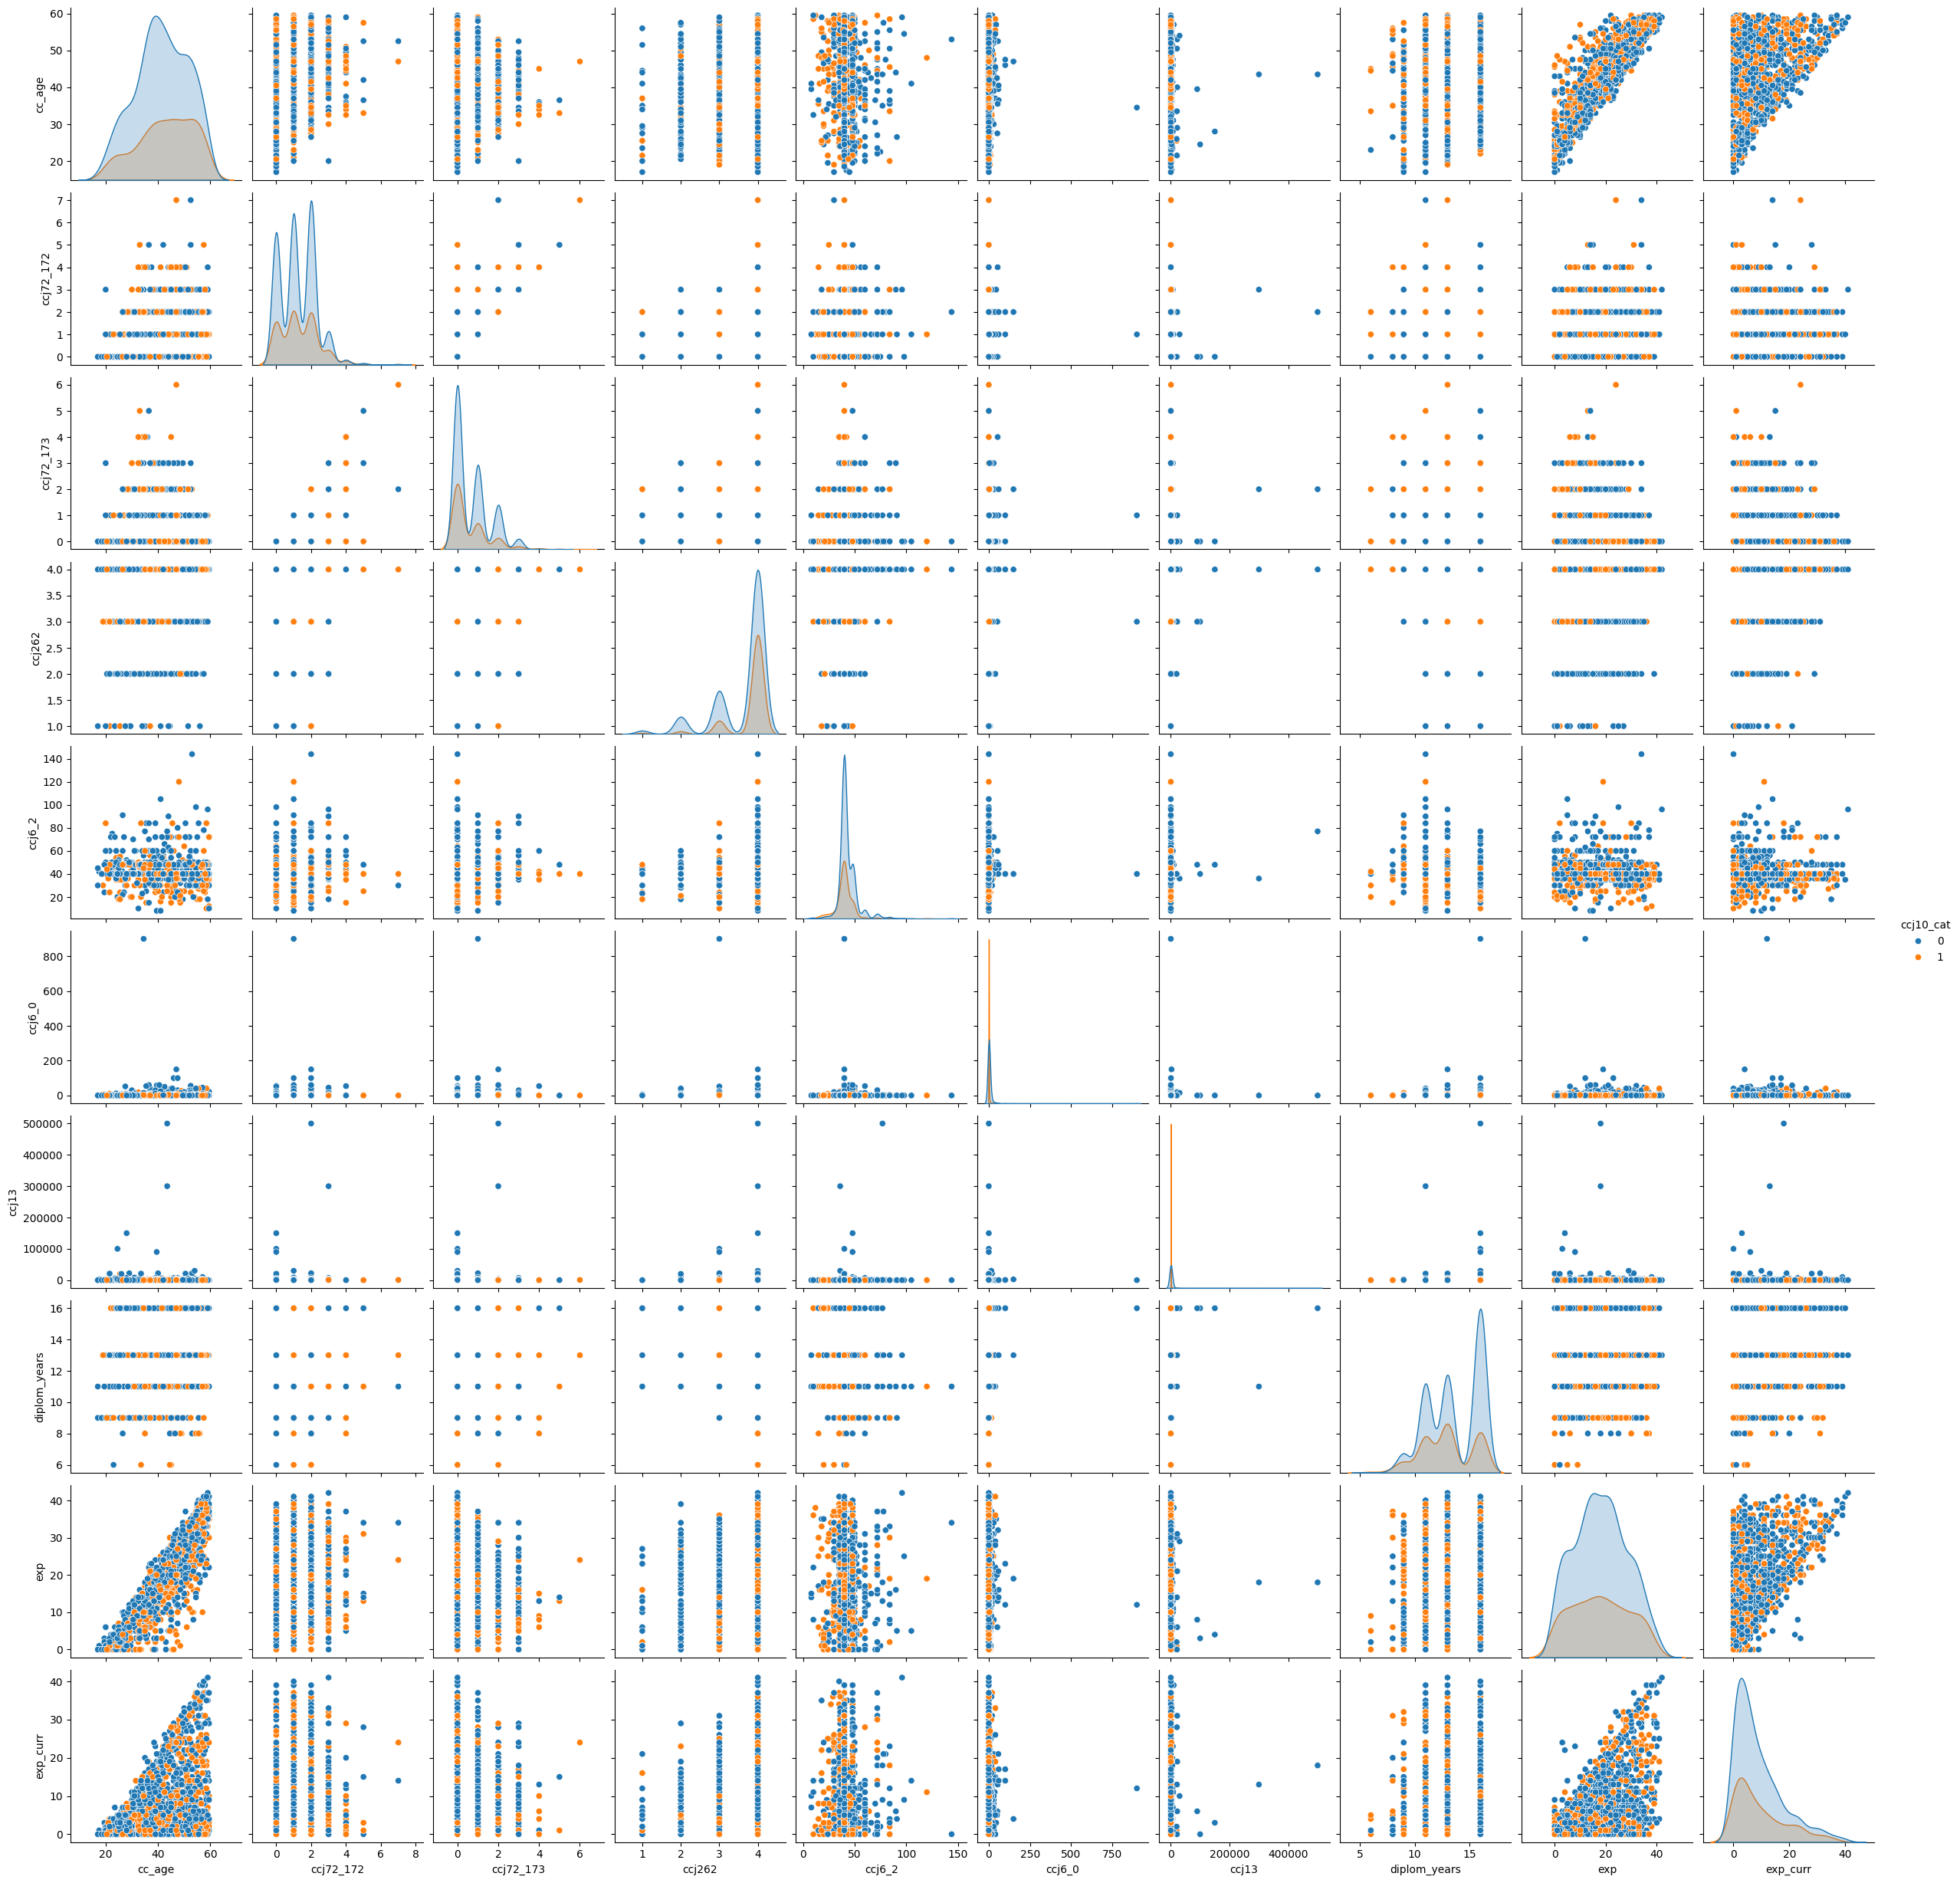

In [558]:
%%time
# Визуализируем числовые признаки попарно на обучающей выборке
sns.pairplot(df_train[df_train.columns[:11]], hue='ccj10_cat');

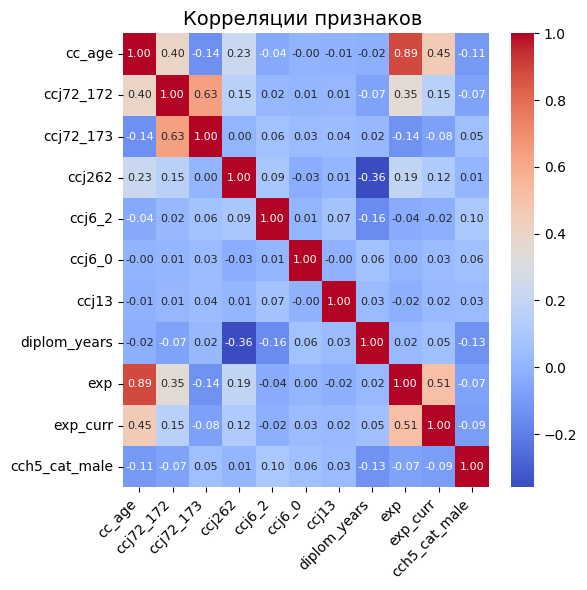

CPU times: user 527 ms, sys: 5.99 ms, total: 533 ms
Wall time: 549 ms


In [559]:
%%time
# Построим парные корреляции Пирсона между числовыми признаками на обучающем датасете
plt.figure(figsize=(6, 6))
corr = features_df_train[features_df_train.columns[:11]].corr()
sns.heatmap(
    corr,
    annot=True,              # показываем значения
    fmt='.2f',               # 2 знака после запятой
    cmap='coolwarm',         # цветовая схема
    annot_kws={'size': 8}    # размер шрифта аннотаций
)
plt.title('Корреляции признаков ', fontsize=14)
plt.xticks(rotation=45, ha='right')  # поворот подписей по X
plt.yticks(rotation=0)               # подписи по Y горизонтально
plt.tight_layout()
plt.show();

cc_age
0.5451101564221195 0.09022031284423893


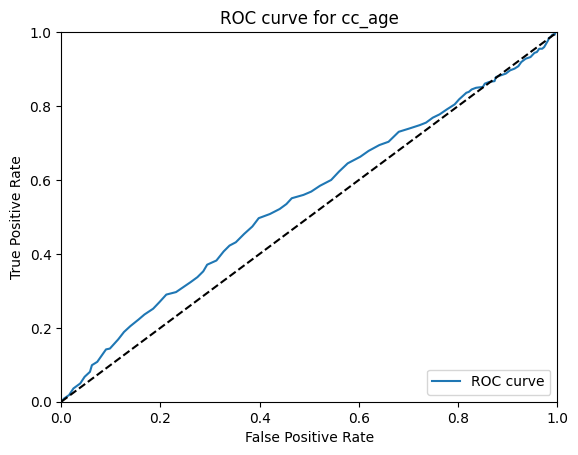

-----------------------------------------------------------------------------------------
ccj72_172
0.5135988103106411 0.02719762062128228


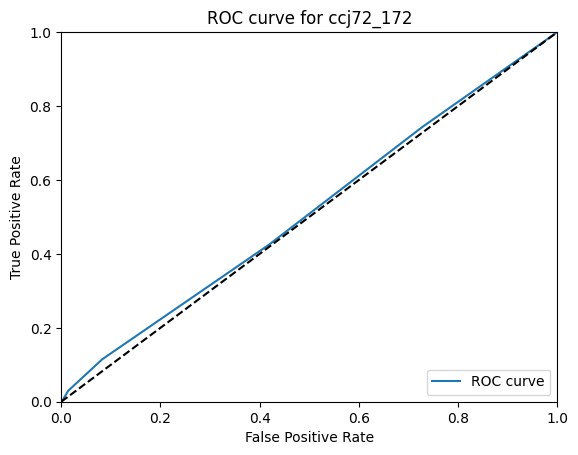

-----------------------------------------------------------------------------------------
ccj72_173
0.4631857237276934 -0.0736285525446132


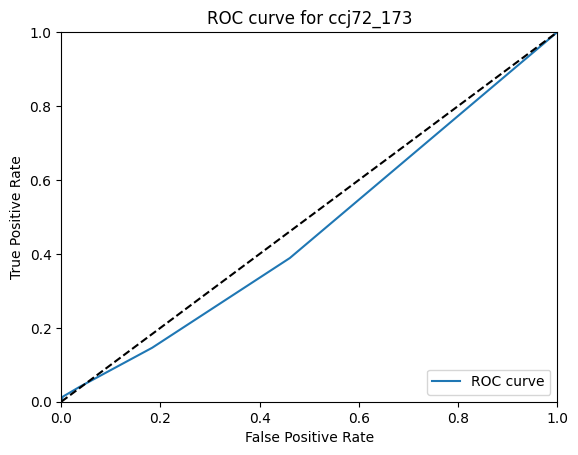

-----------------------------------------------------------------------------------------
ccj262
0.5686902401410002 0.13738048028200045


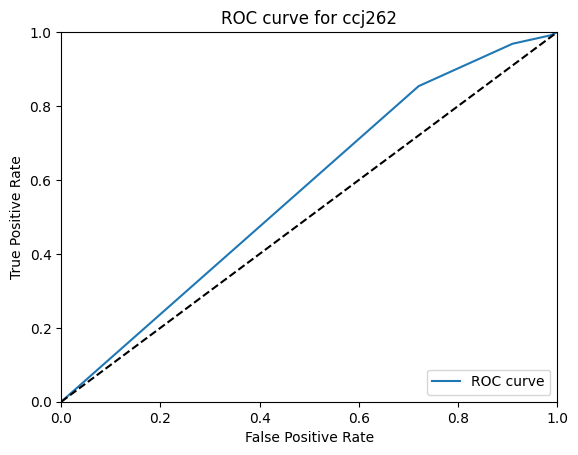

-----------------------------------------------------------------------------------------
ccj6_2
0.4079654108834544 -0.1840691782330912


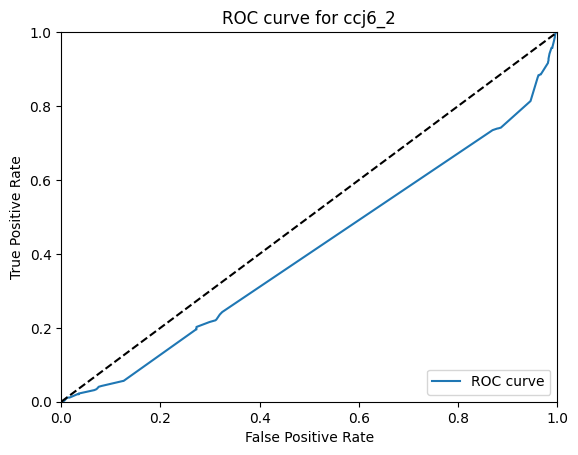

-----------------------------------------------------------------------------------------
ccj6_0
0.44290592641551 -0.11418814716897996


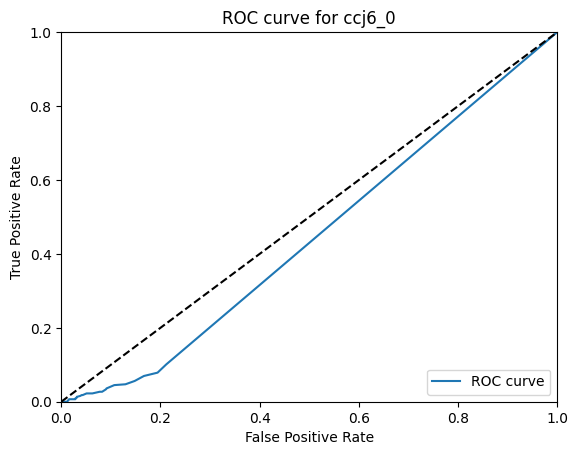

-----------------------------------------------------------------------------------------
ccj13
0.32238708966732754 -0.3552258206653449


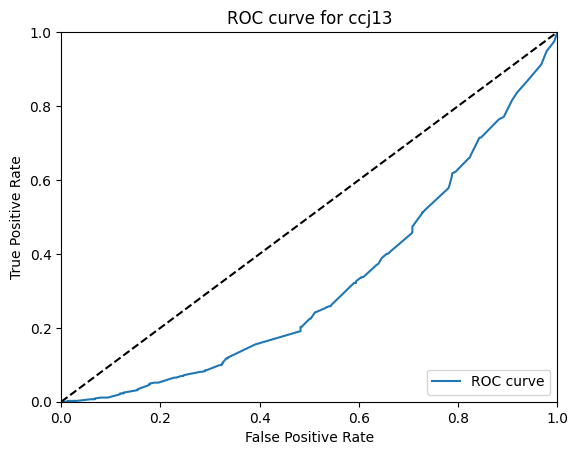

-----------------------------------------------------------------------------------------
ccj10_cat
1.0 1.0


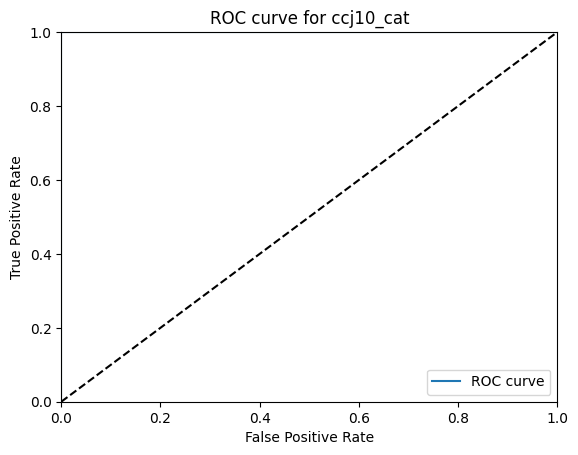

-----------------------------------------------------------------------------------------
diplom_years
0.4282143643974444 -0.14357127120511115


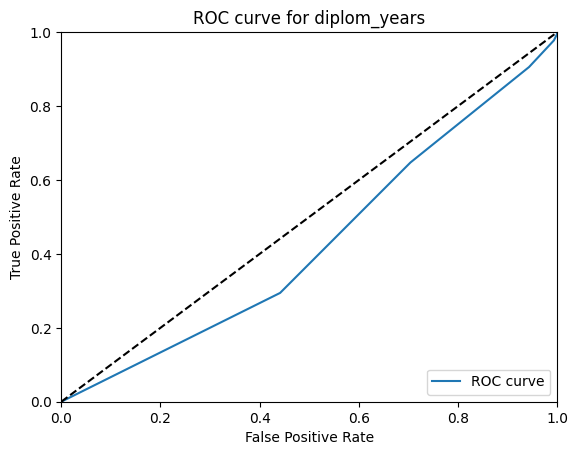

-----------------------------------------------------------------------------------------
exp
0.4955573914959242 -0.008885217008151591


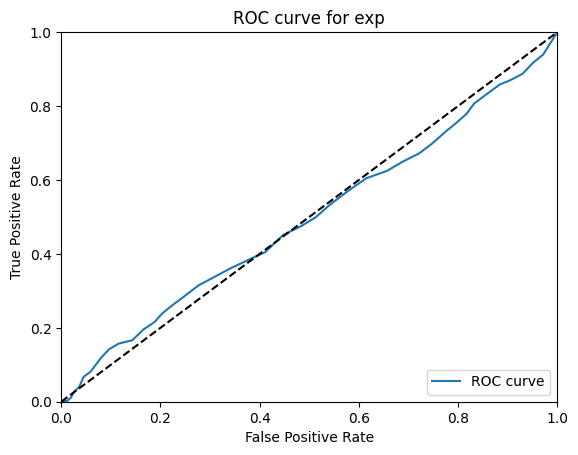

-----------------------------------------------------------------------------------------
exp_curr
0.5116997135933025 0.023399427186604926


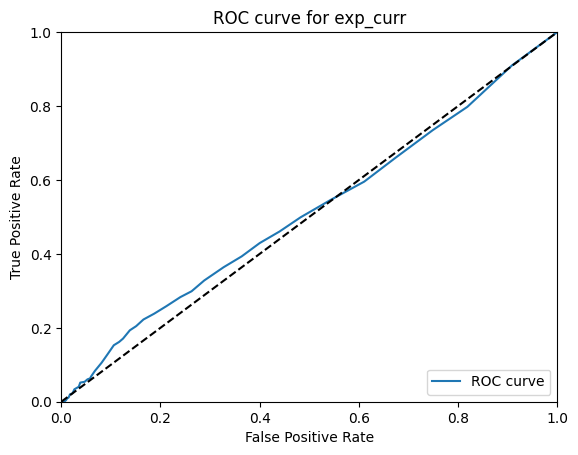

-----------------------------------------------------------------------------------------
cch5_cat_male
0.3617041198501872 -0.2765917602996256


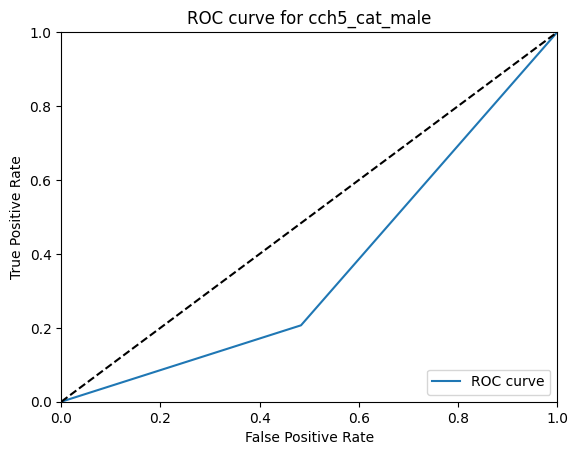

-----------------------------------------------------------------------------------------
cc_marst_cat_not_married
0.4964089006389073 -0.007182198722185396


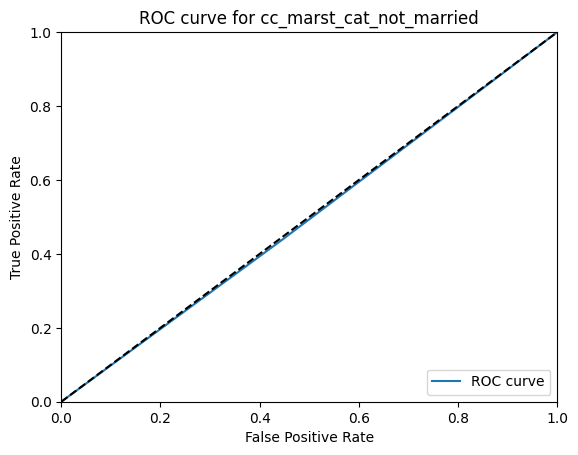

-----------------------------------------------------------------------------------------
ccj72_171_cat_yes
0.5076944260850408 0.015388852170081568


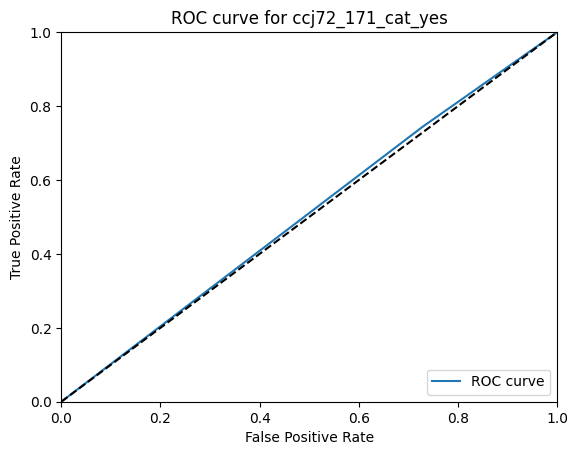

-----------------------------------------------------------------------------------------
cc_diplom_cat_yes
0.4266027759418374 -0.14679444811632525


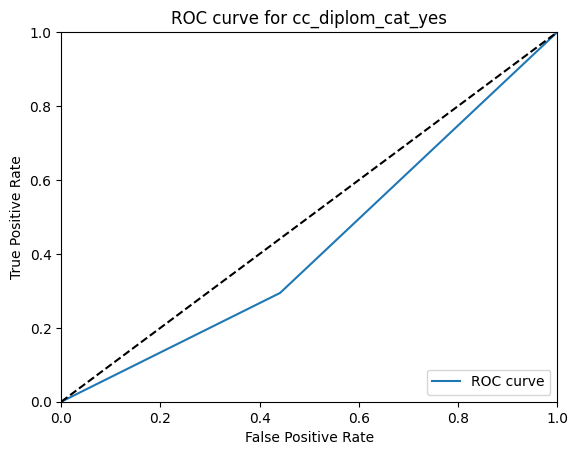

-----------------------------------------------------------------------------------------
ccj260_cat_yes
0.4333278255122273 -0.13334434897554537


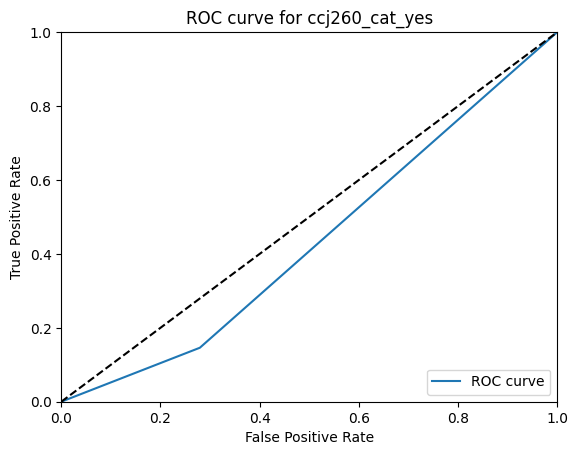

-----------------------------------------------------------------------------------------
status_cat_center_area_high
0.40465961665565103 -0.19068076668869793


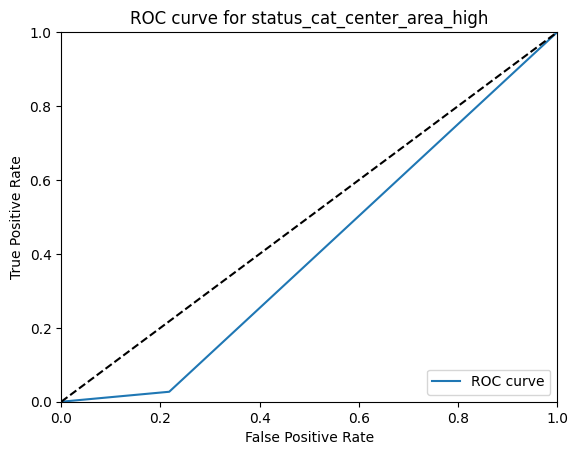

-----------------------------------------------------------------------------------------
status_cat_city
0.49083498567966516 -0.018330028640669682


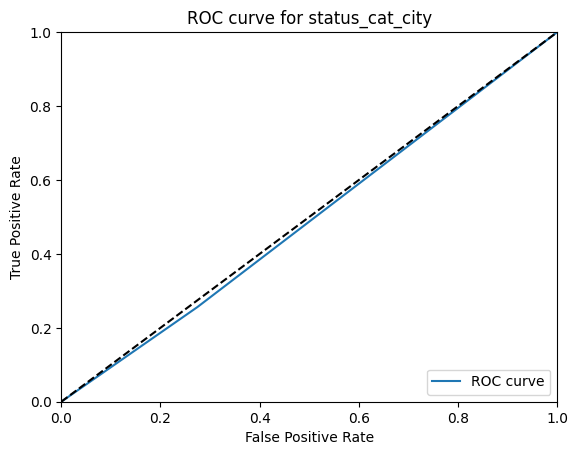

-----------------------------------------------------------------------------------------
status_cat_urban_village
0.5526933245208195 0.10538664904163908


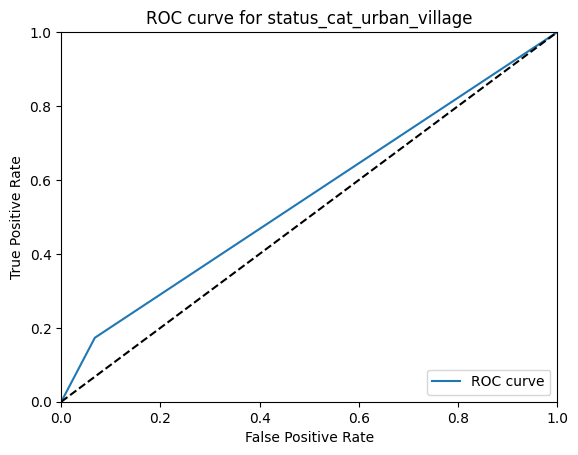

-----------------------------------------------------------------------------------------
status_cat_village
0.5793181317470808 0.1586362634941616


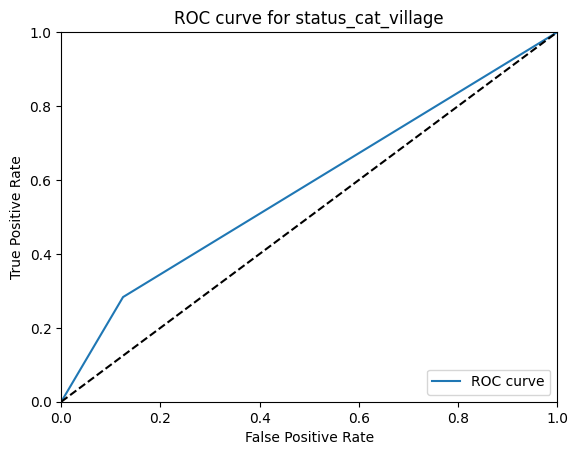

-----------------------------------------------------------------------------------------
cc_occup08_1.0
0.4837243886318572 -0.032551222736285634


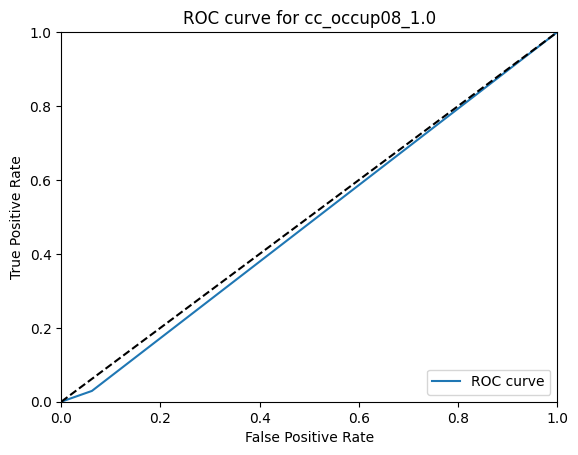

-----------------------------------------------------------------------------------------
cc_occup08_2.0
0.4868252919145187 -0.026349416170962647


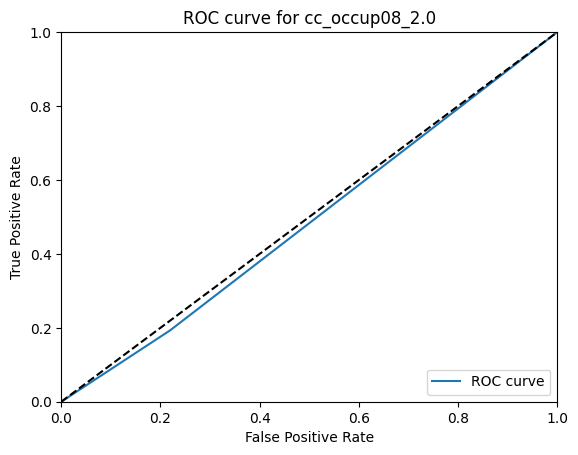

-----------------------------------------------------------------------------------------
cc_occup08_3.0
0.4982485128883014 -0.0035029742233971817


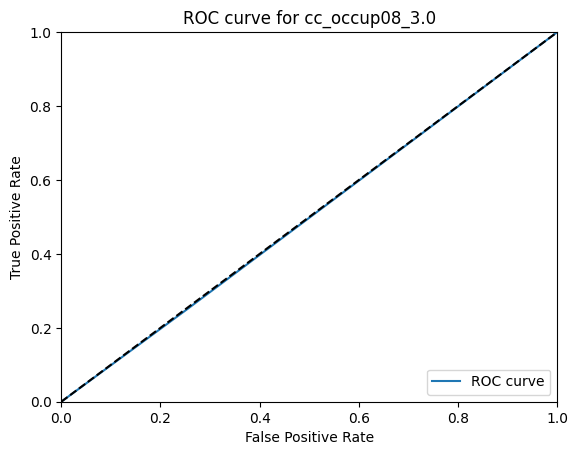

-----------------------------------------------------------------------------------------
cc_occup08_4.0
0.5055628993170301 0.011125798634060269


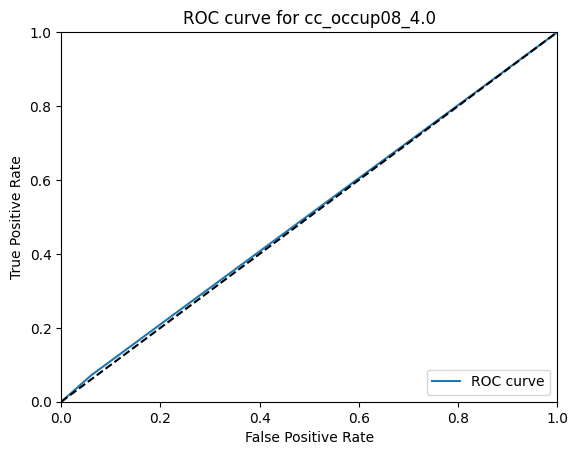

-----------------------------------------------------------------------------------------
cc_occup08_5.0
0.552230667547918 0.1044613350958361


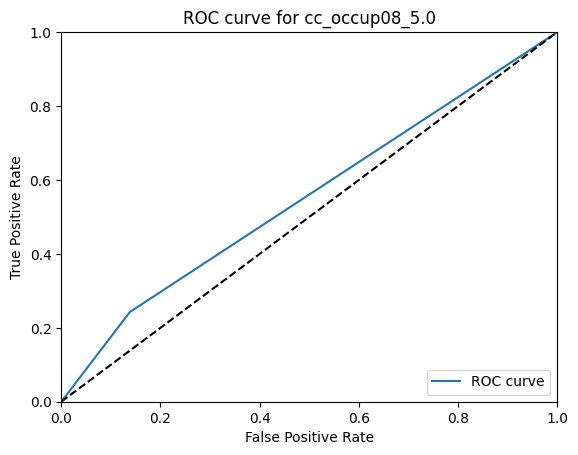

-----------------------------------------------------------------------------------------
cc_occup08_6.0
0.5006333994271867 0.0012667988543733077


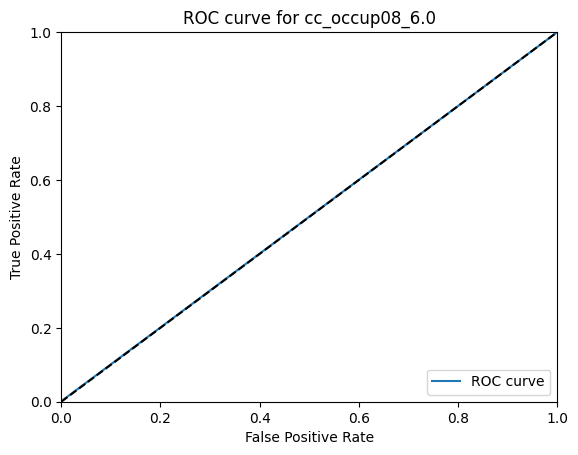

-----------------------------------------------------------------------------------------
cc_occup08_7.0
0.45796981714033924 -0.08406036571932152


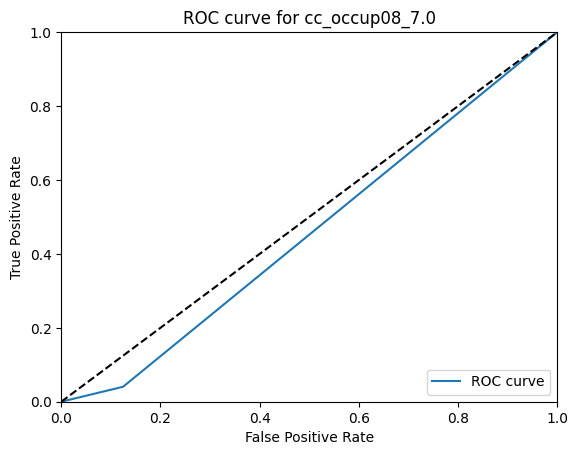

-----------------------------------------------------------------------------------------
cc_occup08_8.0
0.4801938753029302 -0.039612249394139654


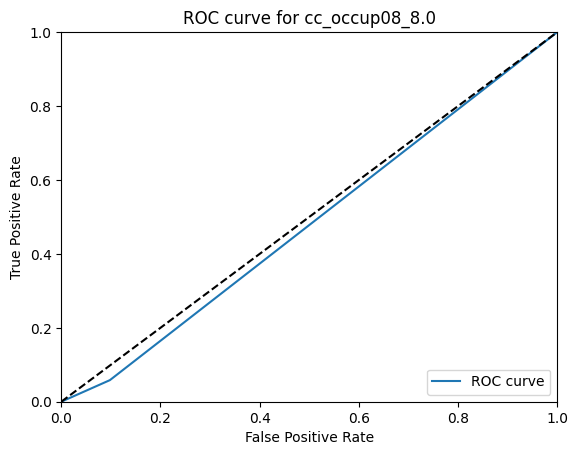

-----------------------------------------------------------------------------------------
cc_occup08_9.0
0.531730557391496 0.06346111478299199


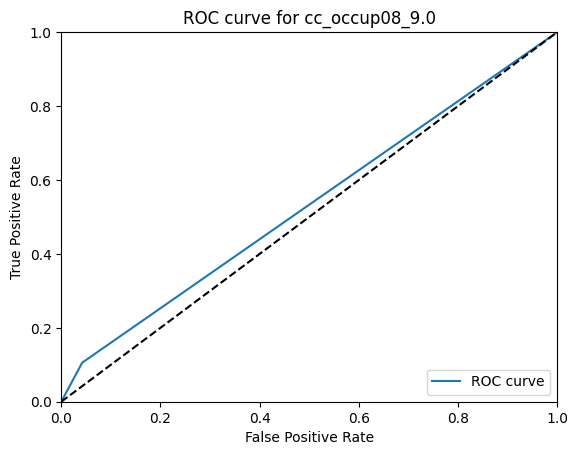

-----------------------------------------------------------------------------------------
ccj4_1_2.0
0.49223948006168755 -0.015521039876624898


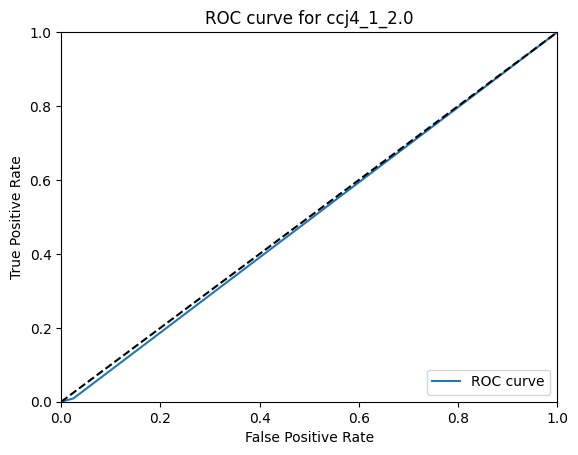

-----------------------------------------------------------------------------------------
ccj4_1_3.0
0.4821491517955497 -0.03570169640890064


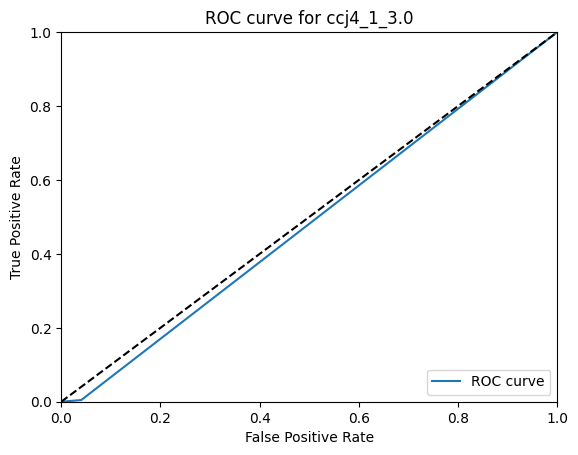

-----------------------------------------------------------------------------------------
ccj4_1_4.0
0.49777484027318797 -0.004450319453624063


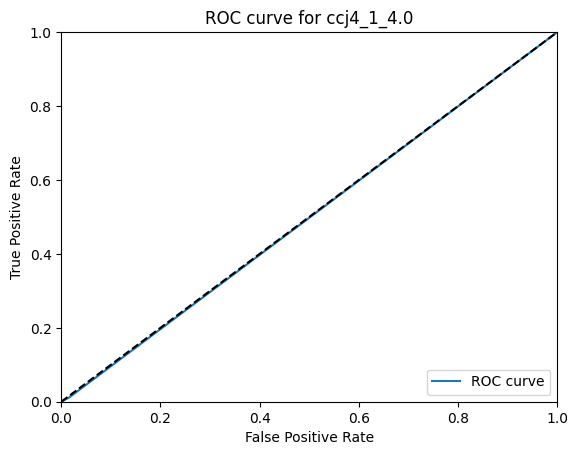

-----------------------------------------------------------------------------------------
ccj4_1_5.0
0.47949438202247185 -0.04101123595505629


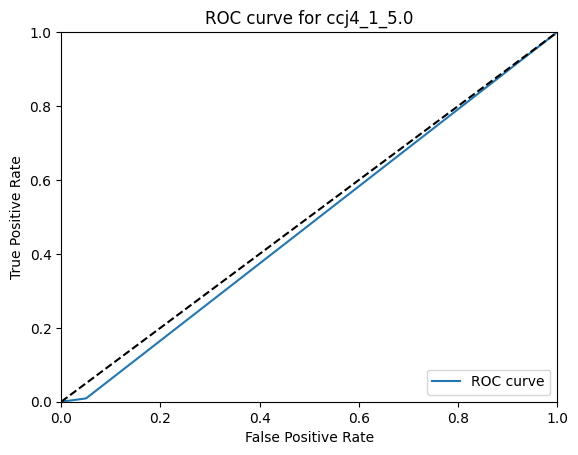

-----------------------------------------------------------------------------------------
ccj4_1_6.0
0.4860927517074245 -0.027814496585151005


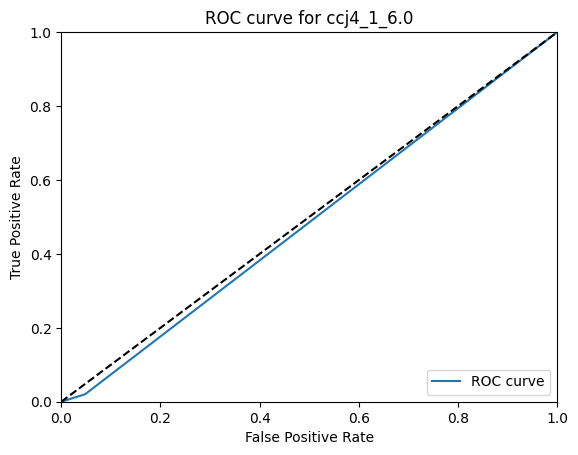

-----------------------------------------------------------------------------------------
ccj4_1_7.0
0.47584269662921347 -0.04831460674157306


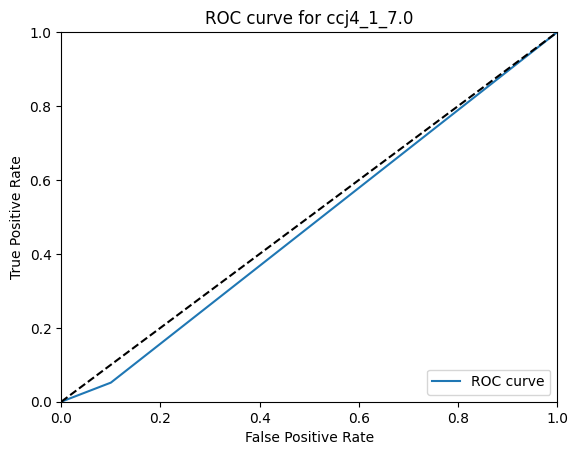

-----------------------------------------------------------------------------------------
ccj4_1_8.0
0.5017184401850627 0.0034368803701254613


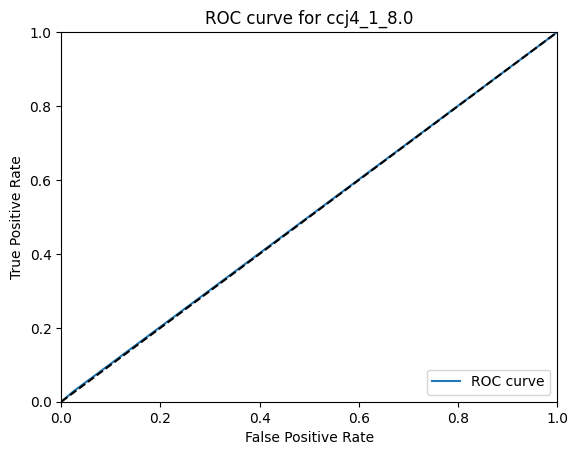

-----------------------------------------------------------------------------------------
ccj4_1_9.0
0.5219431592861864 0.043886318572372796


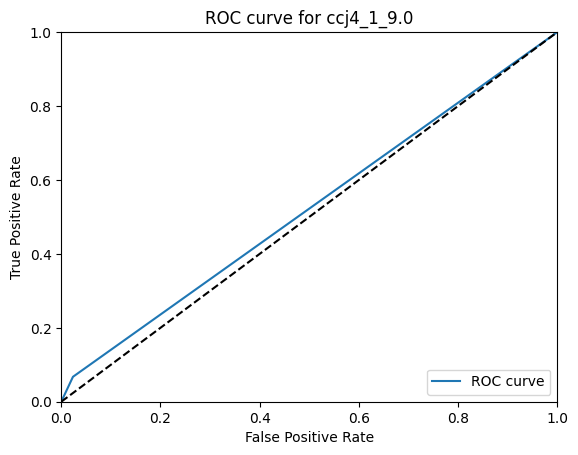

-----------------------------------------------------------------------------------------
ccj4_1_10.0
0.5465245648821326 0.09304912976426527


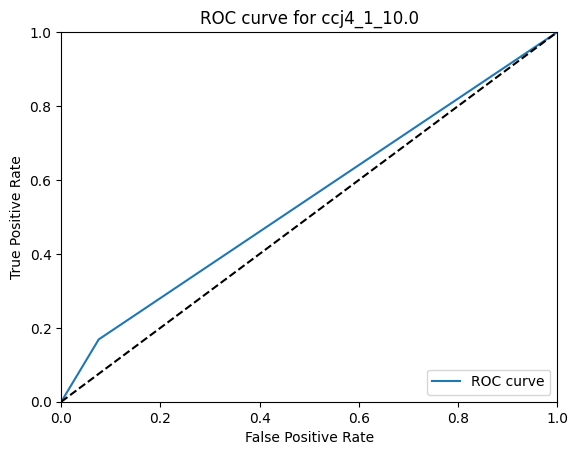

-----------------------------------------------------------------------------------------
ccj4_1_11.0
0.5129543952412426 0.02590879048248529


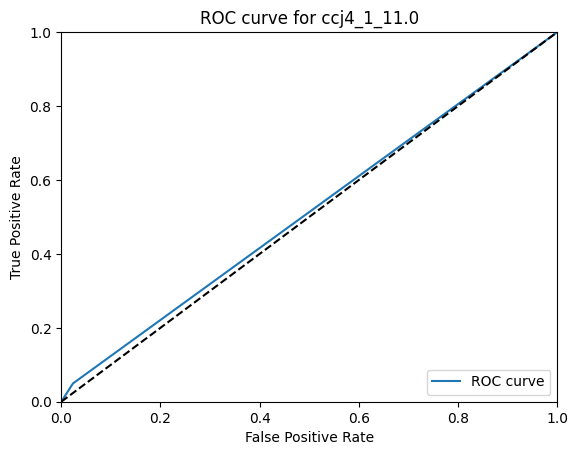

-----------------------------------------------------------------------------------------
ccj4_1_12.0
0.5178233090989205 0.035646618197840985


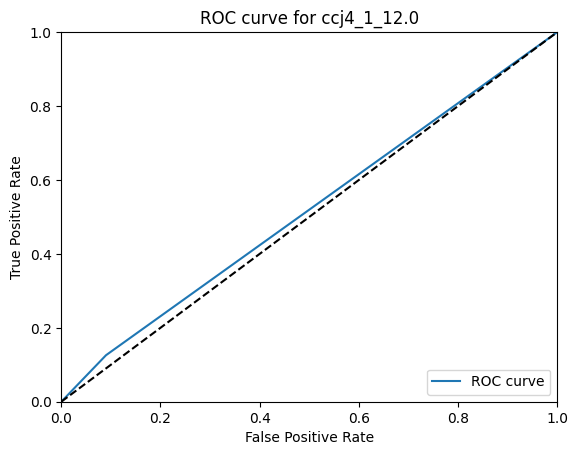

-----------------------------------------------------------------------------------------
ccj4_1_13.0
0.503905045164133 0.007810090328266073


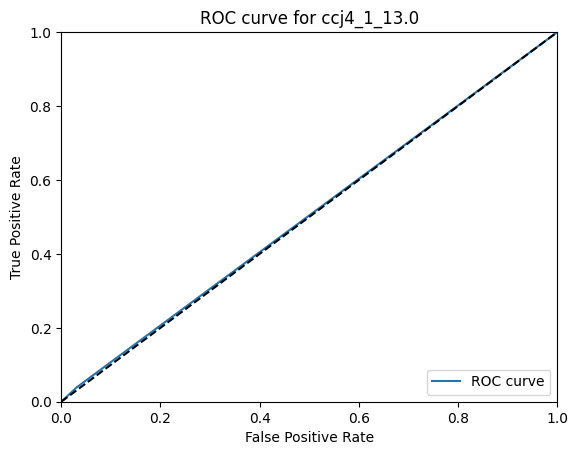

-----------------------------------------------------------------------------------------
ccj4_1_14.0
0.503354263053536 0.006708526107072066


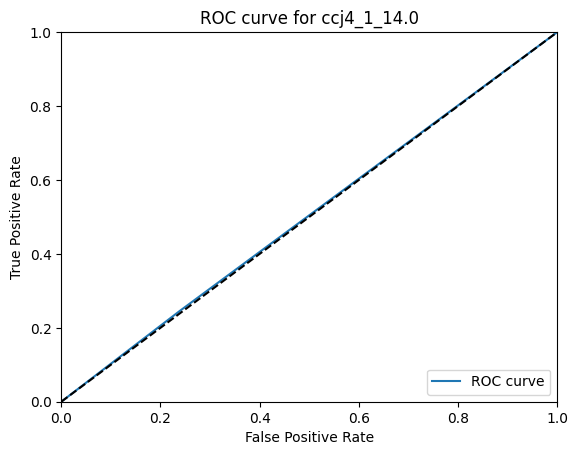

-----------------------------------------------------------------------------------------
ccj4_1_15.0
0.4957534699272968 -0.008493060145406406


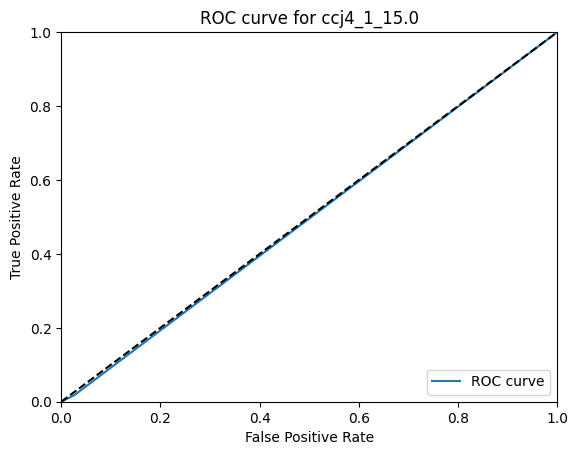

-----------------------------------------------------------------------------------------
ccj4_1_16.0
0.4927296761401189 -0.014540647719762156


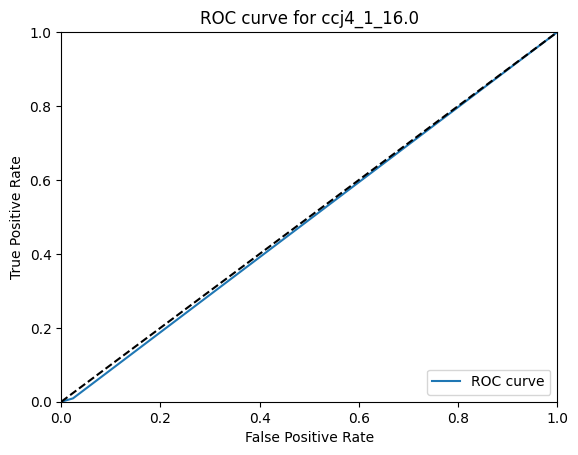

-----------------------------------------------------------------------------------------
ccj4_1_17.0
0.5004736726151134 0.0009473452302268814


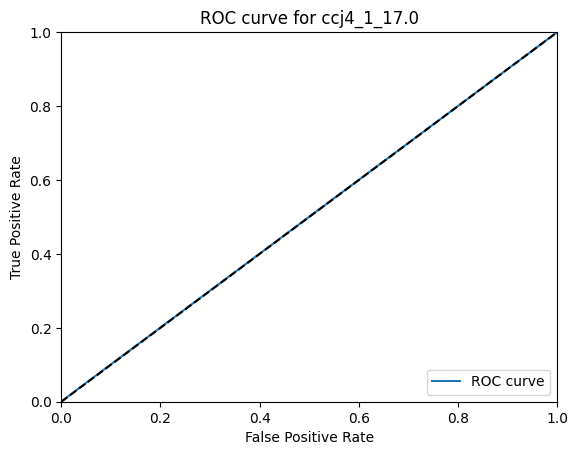

-----------------------------------------------------------------------------------------
ccj4_1_18.0
0.4970588235294118 -0.00588235294117645


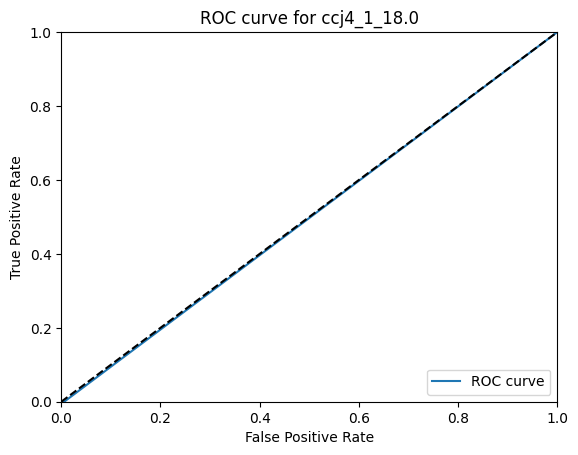

-----------------------------------------------------------------------------------------
ccj4_1_20.0
0.5015532055518837 0.0031064111037673037


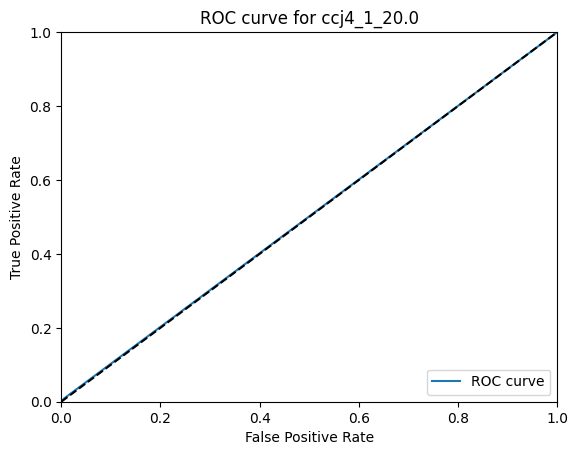

-----------------------------------------------------------------------------------------
ccj4_1_21.0
0.4996530072703239 -0.0006939854593521755


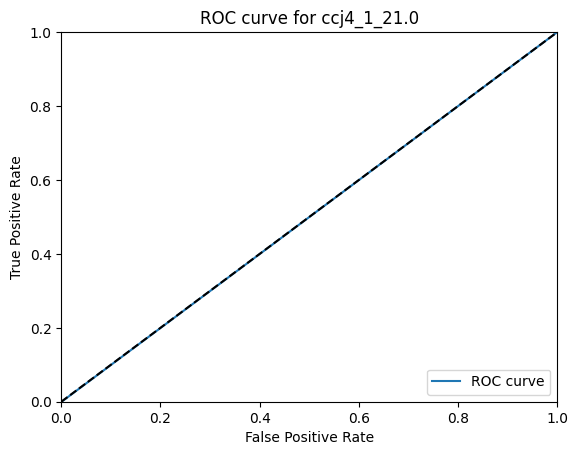

-----------------------------------------------------------------------------------------
ccj4_1_22.0
0.49950980392156863 -0.0009803921568627416


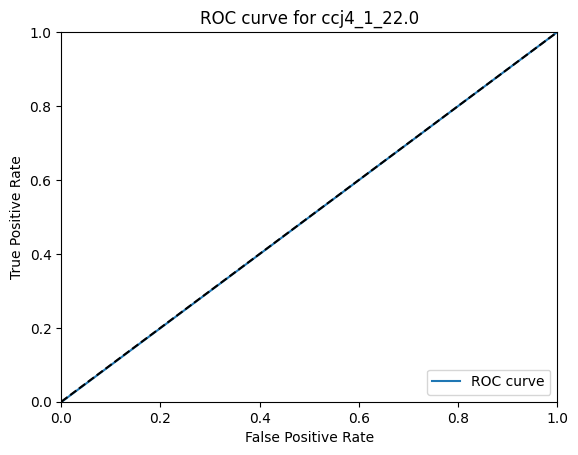

-----------------------------------------------------------------------------------------
ccj4_1_23.0
0.4978354263053536 -0.004329147389292798


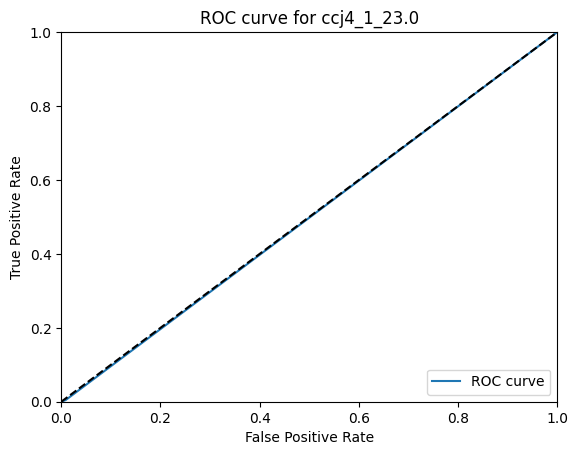

-----------------------------------------------------------------------------------------
ccj4_1_24.0
0.5014100022031285 0.0028200044062569596


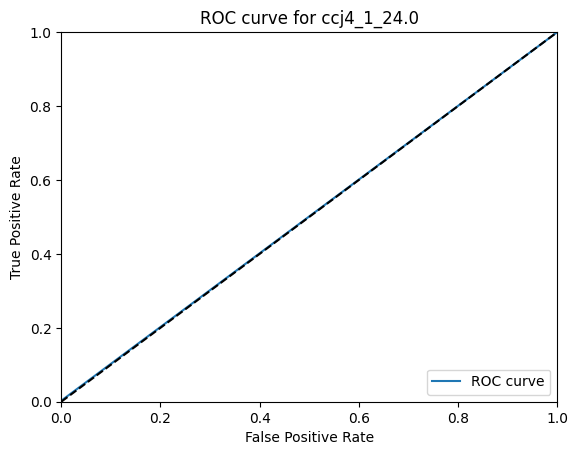

-----------------------------------------------------------------------------------------
ccj4_1_25.0
0.5014100022031285 0.0028200044062569596


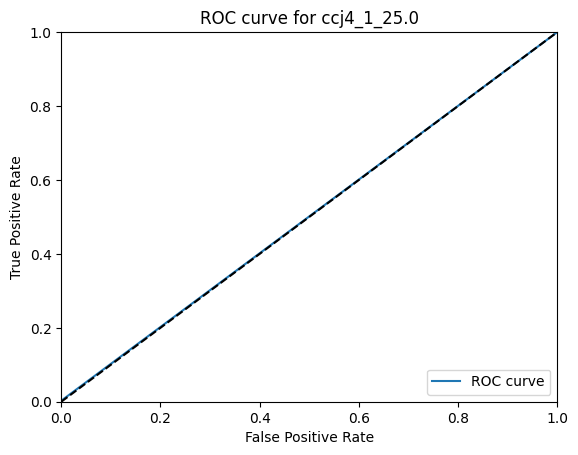

-----------------------------------------------------------------------------------------
ccj4_1_26.0
0.502043401630315 0.004086803260630045


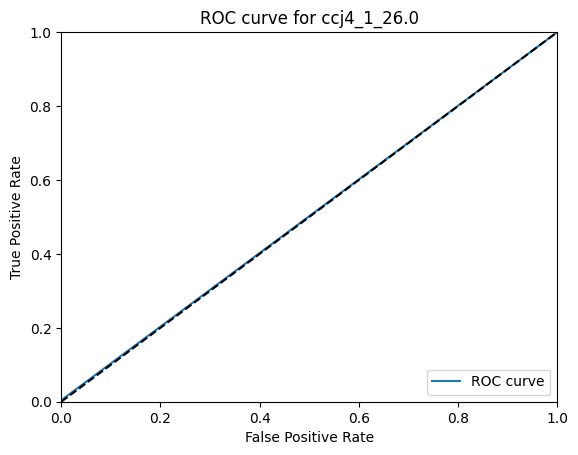

-----------------------------------------------------------------------------------------
ccj4_1_27.0
0.4886649041639128 -0.022670191672174433


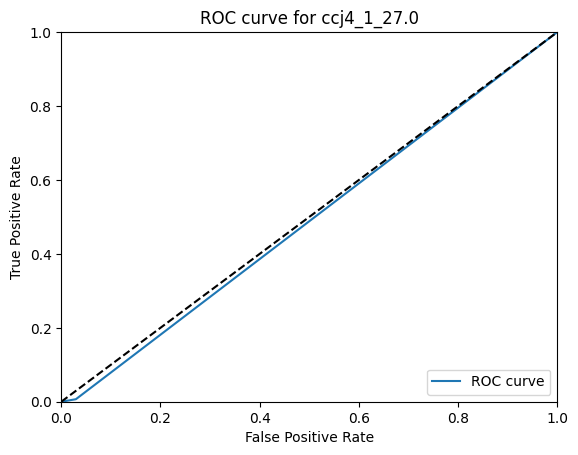

-----------------------------------------------------------------------------------------
ccj4_1_28.0
0.5006333994271867 0.0012667988543733077


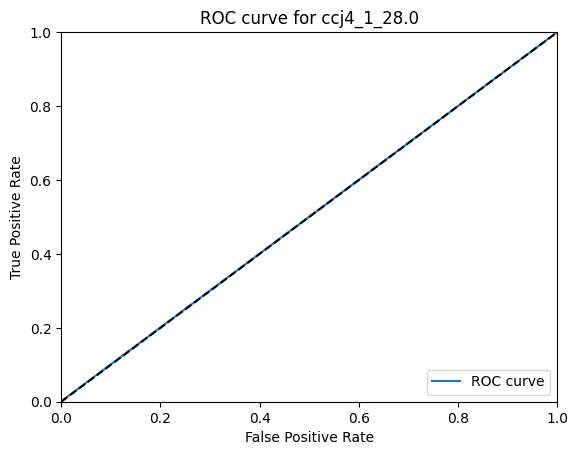

-----------------------------------------------------------------------------------------
ccj4_1_29.0
0.5006333994271867 0.0012667988543733077


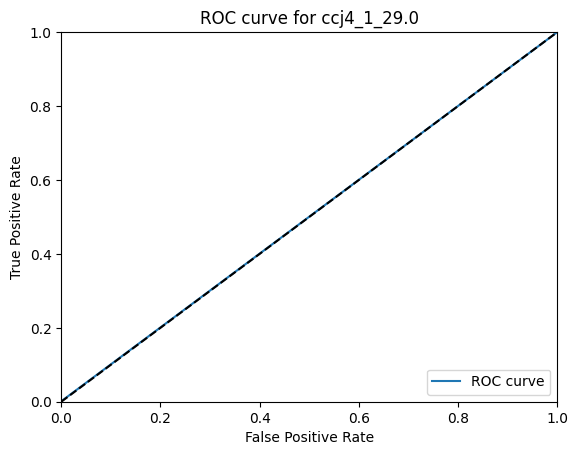

-----------------------------------------------------------------------------------------
ccj4_1_30.0
0.49720202687816706 -0.0055959462436658836


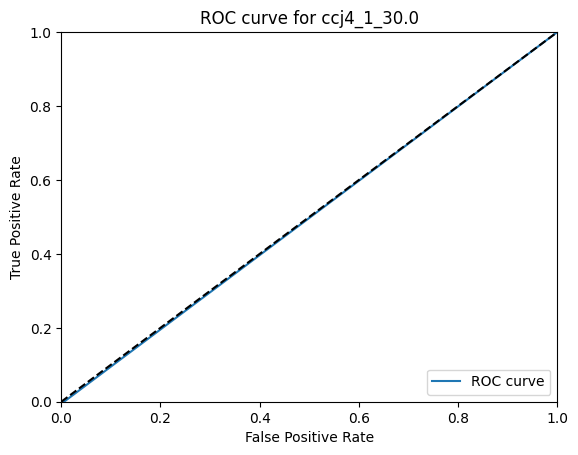

-----------------------------------------------------------------------------------------
ccj4_1_31.0
0.5 0.0


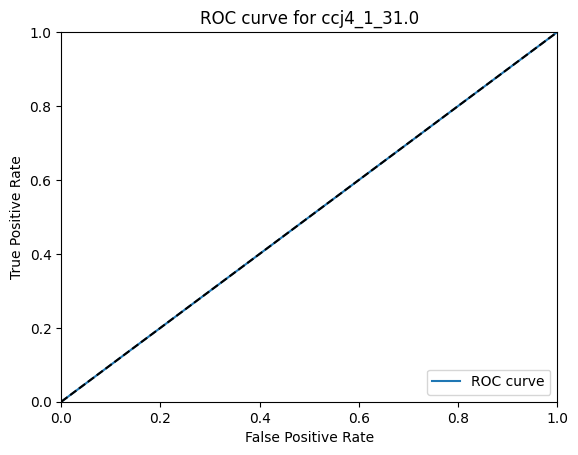

-----------------------------------------------------------------------------------------
ccj6_cat_yes
0.4446794448116325 -0.11064111037673496


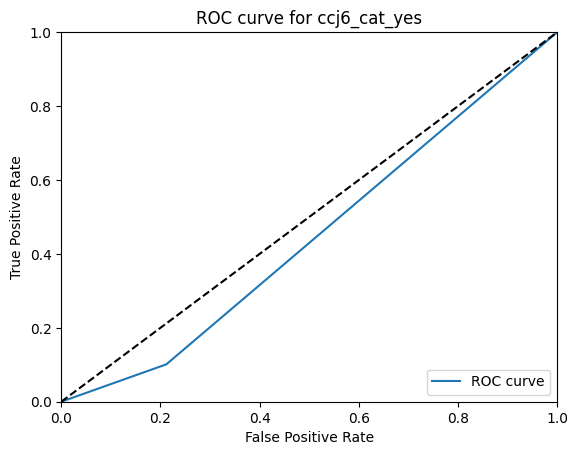

-----------------------------------------------------------------------------------------
ccj23_yes
0.5795274289491077 0.15905485789821538


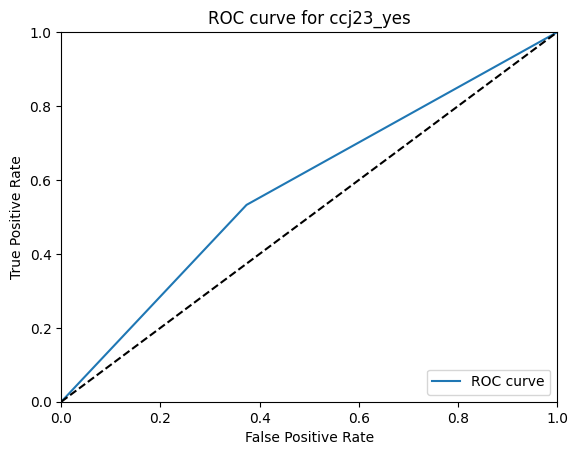

-----------------------------------------------------------------------------------------
CPU times: user 10.6 s, sys: 170 ms, total: 10.7 s
Wall time: 11.2 s


In [560]:
%%time
# Выведем график ROC curve и значения roc auc, Gini на обучающей выборке
gini_dict={}
for v in df_train.columns:
  print(v)
  fpr_1, tpr_1, thresholds_1 = roc_curve(df_train['ccj10_cat'], df_train[f'{v}'])
  plt.plot(fpr_1, tpr_1, label='ROC curve')
  plt.plot([0, 1], [0, 1], 'k--') # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'ROC curve for {v}')
  plt.legend(loc="lower right")
  auc_roc = roc_auc_score(df_train['ccj10_cat'], df_train[f'{v}'])
  print(auc_roc, 2*auc_roc-1)
  gini_dict[v]=2*auc_roc-1
  plt.show()
  print('-----------------------------------------------------------------------------------------')

Выдвинем предположение о спецификации модели: с помощью решающего дерева, случайного леса можно определить класс респондента (зп более 30/менее 30 тыс руб за последние 30 дней). Для проверки предположения и подбора лучшей модели: обучим модели с применением техник борьбы с дисбалансом классов; подсчитаем скорость обучения; подсчитаем метрики качества (accuracy, precision, recall, F1-меру, матрицу ошибок, AUC-ROC, Gini = 2*AUC-ROC - 1); подберем гиперпараметры моделей на валидационной выборке; сравним с baseline; выберем и сохраним модель с лучшими показателями качества.

#### **Обучение моделей**

Чтобы увеличить качество модели при дисбалансе классов, существуют техники: взвешивание классов, upsampling, downsampling.

In [561]:
# Выведем содержимое target_df_train
target_df_train.value_counts()

,count
ccj10_cat,
0,1020
1,445


In [562]:
# Функция для Апсемплинг
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones]* repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones]* repeat)
    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=random_state)
    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_df_train, target_df_train, repeat=2)

print(features_upsampled.shape)
print(target_upsampled.shape)

(1910, 59)
(1910,)


In [563]:
# Выведем содержимое target_upsampled
target_upsampled.value_counts()

,count
ccj10_cat,
0,1020
1,890


Выборка стала сбалансированной, соотношение классов примерно 1:1.

##### **Обучение Decision Tree**

In [564]:
%%time
# Сохраним модель Decision Tree в переменной model
model = DecisionTreeClassifier(random_state=random_state) # значения гиперпараметров установлены по умолчанию
# Обучим модель на апсемплинг выборке
model.fit(features_upsampled, target_upsampled)

# Расчет метрик на обучающей выборке
print('-----Обучающая выборка-----')
train_predictions = model.predict(features_df_train) # Сделаем предсказания по обученной модели на обучающей выборке
accuracy = accuracy_score(target_df_train, train_predictions)
f1 = f1_score(target_df_train, train_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_train, train_predictions) # посчитаем precision для модели
recall = recall_score(target_df_train, train_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))

# Расчет метрик на валидационной выборке
print('-----Валидационная выборка-----')
valid_predictions = model.predict(features_df_valid) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_valid, valid_predictions)
f1 = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
recall = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))

-----Обучающая выборка-----
Accuracy 1.0
F1 1.0
Precision 1.0
Recall 1.0
-----Валидационная выборка-----
Accuracy 0.627
F1 0.372
Precision 0.367
Recall 0.378
CPU times: user 48.6 ms, sys: 0 ns, total: 48.6 ms
Wall time: 49.6 ms


Похоже, что модель переобучилась (качество модели сильно упало на валидационной выборке). Выведем параметры обучающего дерева:

In [565]:
print('Глубина дерева:', model.get_depth()), print('Количество листьев:', model.get_n_leaves())
print('min_samples_split:', model.min_samples_split), print('min_samples_leaf:',  model.min_samples_leaf)
print(model.get_params());

Глубина дерева: 22
Количество листьев: 292
min_samples_split: 2
min_samples_leaf: 1
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 12345, 'splitter': 'best'}


Исследуем метрики качества модели на валидационной выборке в зависимости от глубины и количества листьев.

In [566]:
%%time
for depth in range(3, 20, 1):
    for i in range(10, 100, 1):
        model = DecisionTreeClassifier(random_state=random_state, max_leaf_nodes=i, max_depth=depth) # сохраняем модель с заданными параметрами
        model.fit(features_upsampled, target_upsampled) # обучаем модель на тренировочной выборке
        valid_predictions = model.predict(features_df_valid) # получим предсказания модели
        accuracy = accuracy_score(target_df_valid, valid_predictions) # посчитаем accuracy для модели
        f1 = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
        precision = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
        recall = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
        print(depth, "    ", i, "    ", accuracy, "   ", f1, "   ", precision, "   ", recall)

3      10      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      11      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      12      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      13      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      14      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      15      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      16      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      17      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      18      0.7131147540983607     0.554140127388535     0.5087719298245614     0.6083916083916084
3      19      0.7131147540983607     0.554140127388535     0.5087719298245614    

Наибольшая метрика accuracy=0,713 и достигается при depth = 3 и max_leaf_nodes = 11. Вторая по величине метрика accuracy=0,70 и достигается при depth = 5 и max_leaf_nodes = 15. Выберем именно depth = 5 и max_leaf_nodes = 15, так как при этих гиперпараметрах больше recall.

In [591]:
%%time
# Сохраним модель
model = DecisionTreeClassifier(random_state=random_state, max_leaf_nodes=15, max_depth=5) # значения гиперпараметров установлены по умолчанию
# Обучим модель
model.fit(features_upsampled, target_upsampled)

# Расчет метрик на обучающей выборке
print('-----Обучающая выборка-----')
train_predictions = model.predict(features_df_train) # Сделаем предсказания по обученной модели на обучающей выборке
accuracy = accuracy_score(target_df_train, train_predictions)
f1 = f1_score(target_df_train, train_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_train, train_predictions) # посчитаем precision для модели
recall = recall_score(target_df_train, train_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_train, train_predictions))

# Расчет метрик на валидационной выборке
print('-----Тестовая выборка-----')
valid_predictions = model.predict(features_df_valid) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_valid, valid_predictions)
f1 = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
recall = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_valid, valid_predictions))

# Расчет метрик на тестовой выборке
print('-----Тестовая выборка-----')
test_predictions = model.predict(features_df_test) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_test, test_predictions)
f1 = f1_score(target_df_test, test_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_test, test_predictions) # посчитаем precision для модели
recall = recall_score(target_df_test, test_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_test, test_predictions))

# Вывод параметров
print('-----Вывод параметров-----')
print('Глубина дерева:', model.get_depth()), print('Количество листьев:', model.get_n_leaves())
print('min_samples_split:', model.min_samples_split), print('min_samples_leaf:',  model.min_samples_leaf)
print(model.get_params());

-----Обучающая выборка-----
Accuracy 0.767
F1 0.652
Precision 0.596
Recall 0.721
confusion_matrix [[802 218]
 [124 321]]
-----Тестовая выборка-----
Accuracy 0.701
F1 0.541
Precision 0.491
Recall 0.601
confusion_matrix [[256  89]
 [ 57  86]]
-----Тестовая выборка-----
Accuracy 0.72
F1 0.596
Precision 0.549
Recall 0.652
confusion_matrix [[251  83]
 [ 54 101]]
-----Вывод параметров-----
Глубина дерева: 5
Количество листьев: 15
min_samples_split: 2
min_samples_leaf: 1
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': 15, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 12345, 'splitter': 'best'}
CPU times: user 97.1 ms, sys: 0 ns, total: 97.1 ms
Wall time: 102 ms


0.6297025776602776
0.4272017837235229
0.4977593200695385


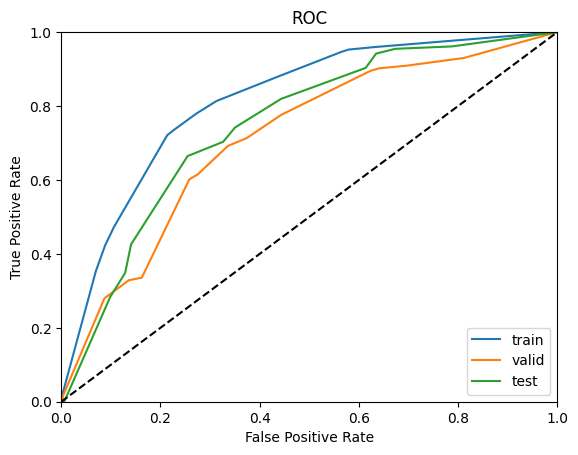

In [592]:
# Предсказываем вероятности
predictions_prob_train = model.predict_proba(features_df_train)
predictions_prob_one_train = predictions_prob_train[:, 1] # Выбираем вероятности отнесения к классу "1"
print(2*roc_auc_score(target_df_train, predictions_prob_one_train)-1)

predictions_prob_valid = model.predict_proba(features_df_valid)
predictions_prob_one_valid = predictions_prob_valid[:, 1] # Выбираем вероятности отнесения к классу "1"
print(2*roc_auc_score(target_df_valid, predictions_prob_one_valid)-1)

predictions_prob_test = model.predict_proba(features_df_test)
predictions_prob_one_test = predictions_prob_test[:, 1] # Выбираем вероятности отнесения к классу "1"
print(2*roc_auc_score(target_df_test, predictions_prob_one_test)-1)

fpr_1, tpr_1, thresholds_1 = roc_curve(target_df_train, predictions_prob_one_train)
fpr_2, tpr_2, thresholds_2 = roc_curve(target_df_valid, predictions_prob_one_valid)
fpr_3, tpr_3, thresholds_3 = roc_curve(target_df_test, predictions_prob_one_test)
plt.plot(fpr_1, tpr_1, label='train')
plt.plot(fpr_2, tpr_2, label='valid')
plt.plot(fpr_3, tpr_3, label='test')
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")

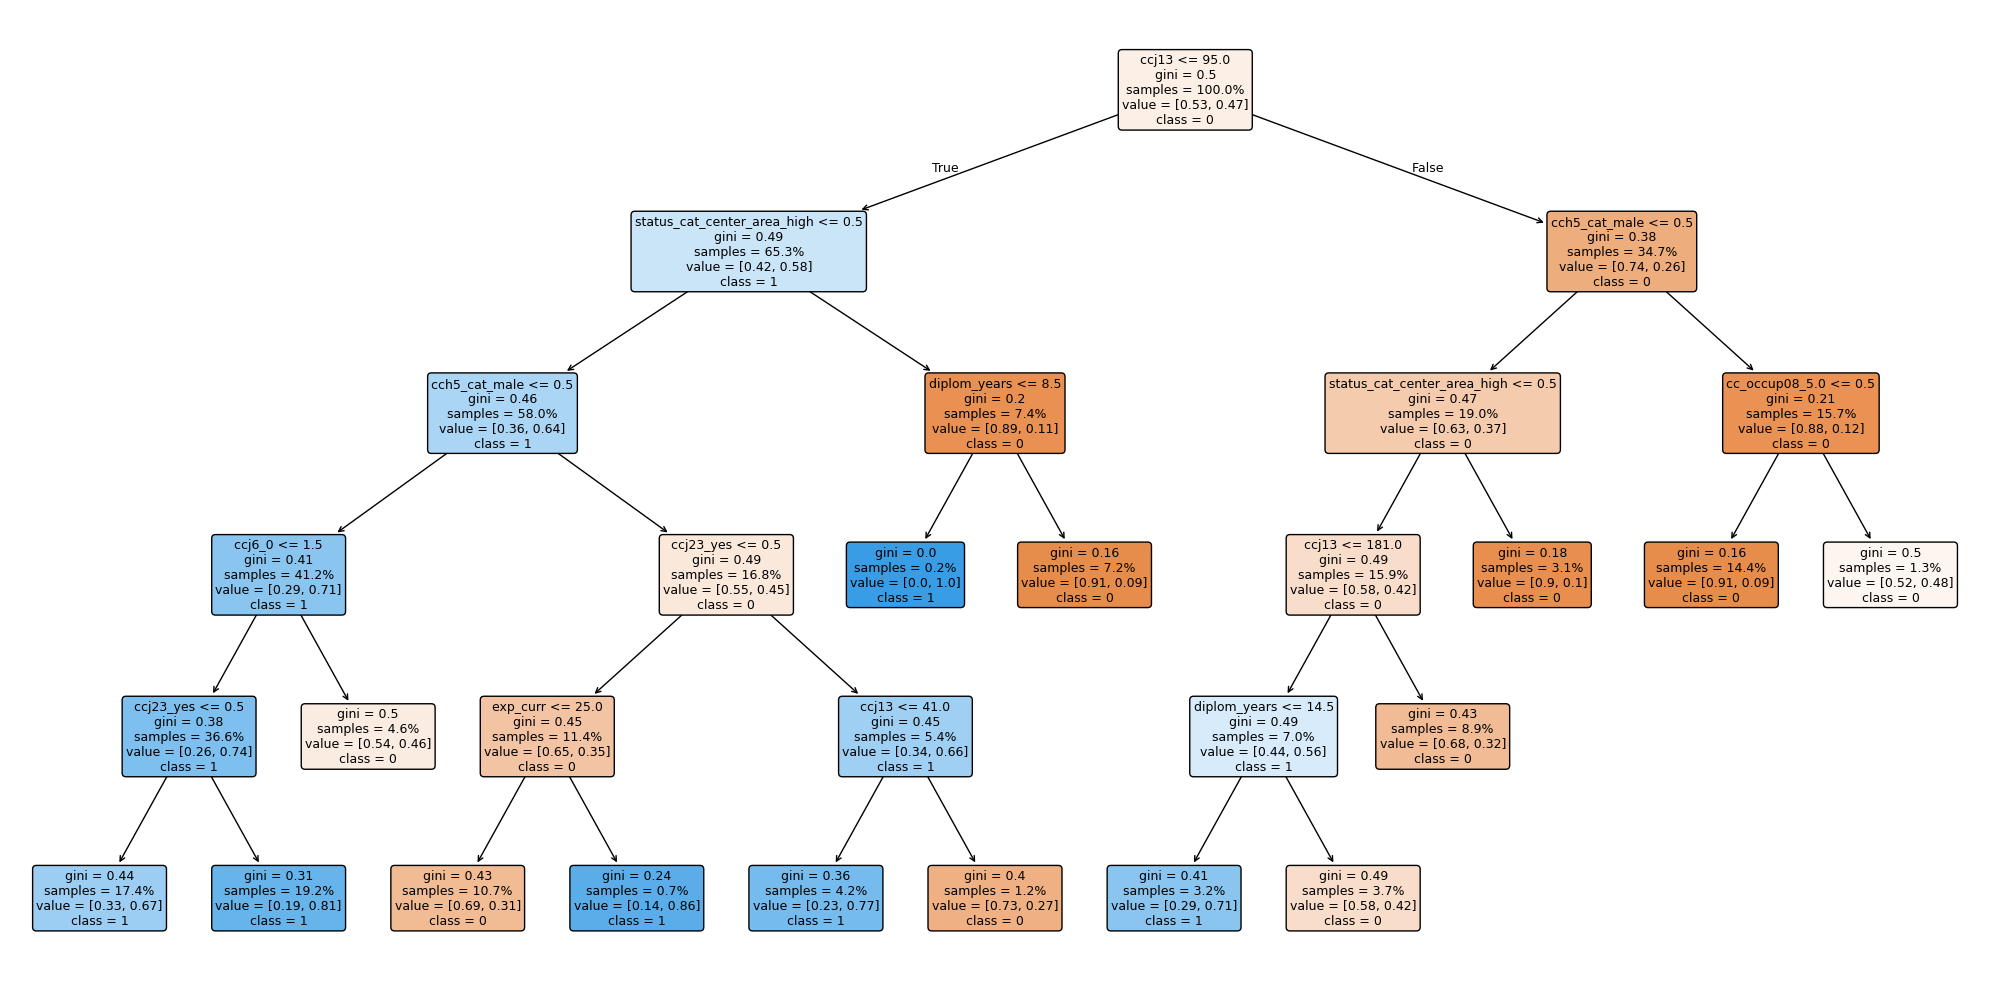

In [593]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    model,
    feature_names=features_df_train.columns,  # читаемые имена признаков
    class_names=[str(c) for c in model.classes_], # читаемые имена классов
    filled=True,          # цвет узлов по классу
    rounded=True,         # скругленные рамки
    impurity=True,        # показывать gini/entropy
    # node_ids=True,        # показывать ID узлов
    proportion=True,      # samples и value в штуках/долях(процентах)
    precision=2,          # 2 знака после запятой
    fontsize=9,
    ax=ax
)
plt.tight_layout()
plt.show()

In [590]:
print(1 - (0.47**2 + 0.53**2))
print(len(features_df_train.columns))

0.4982
59


Приведенный рисунок показывает, что из 59 независимых переменных, которые были изначально определены в обучающей выборке, лишь 8 включены в модель.
Исследуем полученную модель более подробно.

В первую очередь рассмотрим корневой узел. Он описывает полную выборку, которая разделена между двумя категориями целевой переменной: примерно 53% с зп выше 30 тыс руб и около 47% — ниже 30 тыс руб. Неоднородность этого узла можно рассчитать с помощью меры Джини:
1-(0,53^2 + 0,47^2)=0,5. Видим, что уменьшение неоднородности от узла отца к узлам сыновьям не всегда значительная.

Также видим, что модель легко интерпретируема. Разбиение модели на узлы согласуется со здравым смыслом. Наилучшим предиктором для таргета является переменная «ccj13 (численность сотрудников в компании, где работает респондент)».

In [600]:
# Выведем важность фичей
pd.DataFrame({"feature": features_df_train.columns,"importance": model.feature_importances_}).sort_values(by="importance", ascending=False).reset_index(drop=True)[0:8]

,feature,importance
0,ccj13,0.36
1,status_cat_center_area_high,0.26
2,cch5_cat_male,0.18
3,ccj23_yes,0.07
4,ccj6_0,0.04
5,diplom_years,0.04
6,exp_curr,0.03
7,cc_occup08_5.0,0.02


##### **Обучение Random Forest**

In [570]:
model = RandomForestClassifier(random_state=random_state) # значения гиперпараметров установлены по умолчанию
# Обучим модель
model.fit(features_upsampled, target_upsampled)

# Расчет метрик на обучающей выборке
print('-----Обучающая выборка-----')
train_predictions = model.predict(features_df_train) # Сделаем предсказания по обученной модели на обучающей выборке
accuracy = accuracy_score(target_df_train, train_predictions)
f1 = f1_score(target_df_train, train_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_train, train_predictions) # посчитаем precision для модели
recall = recall_score(target_df_train, train_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))

# Расчет метрик на валидационной выборке
print('-----Валидационная выборка-----')
valid_predictions = model.predict(features_df_valid) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_valid, valid_predictions)
f1 = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
recall = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))

-----Обучающая выборка-----
Accuracy 1.0
F1 1.0
Precision 1.0
Recall 1.0
-----Валидационная выборка-----
Accuracy 0.746
F1 0.547
Precision 0.573
Recall 0.524


Похоже, что модель переобучилась (качество модели упало на валидационной выборке). Выведем параметры:

In [571]:
print('Глубина:', model.max_depth), print('Количество деревьев:', model.n_estimators), print('max_features:', model.max_features),
print('min_samples_leaf:', model.min_samples_leaf), print('max_depth:', model.max_depth), print('min_samples_split:', model.min_samples_split);

Глубина: None
Количество деревьев: 100
max_features: sqrt
min_samples_leaf: 1
max_depth: None
min_samples_split: 2


Исследуем метрики качества в зависимости от количества деревьев и max_depth на валидационной выборке:

In [572]:
for est in range(1, 101, 1):
    for i in range(1,20,1):
        model = RandomForestClassifier(random_state=random_state, n_estimators=est, max_depth=i) # сохраняем модель с заданным количеством деревьев
        model.fit(features_upsampled, target_upsampled) # обучаем модель на тренировочной выборке
        train_predictions = model.predict(features_df_train) # получим предсказания модели
        accuracy_t = accuracy_score(target_df_train, train_predictions) # посчитаем accuracy для модели
        f1_t = f1_score(target_df_train, train_predictions) # посчитаем f1 для модели
        precision_t = precision_score(target_df_train, train_predictions) # посчитаем precision для модели
        recall_t = recall_score(target_df_train, train_predictions) # посчитаем recall для модели
        valid_predictions = model.predict(features_df_valid) # получим предсказания модели
        accuracy_v = accuracy_score(target_df_valid, valid_predictions) # посчитаем accuracy для модели
        f1_v = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
        precision_v = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
        recall_v = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
        print(est, "    ", i, "    ", accuracy_t, "   ", f1_t, "   ", precision_t, "   ", recall_t , "   ", accuracy_v, "   ", f1_v, "   ", precision_v, "   ", recall_v)

1      1      0.4204778156996587     0.4851425106124924     0.33222591362126247     0.898876404494382     0.4016393442622951     0.4612546125461255     0.3132832080200501     0.8741258741258742
1      2      0.6443686006825938     0.45100105374077976     0.4246031746031746     0.48089887640449436     0.6065573770491803     0.36423841059602646     0.34591194968553457     0.38461538461538464
1      3      0.6914675767918089     0.3875338753387534     0.4880546075085324     0.32134831460674157     0.6782786885245902     0.3203463203463203     0.42045454545454547     0.25874125874125875
1      4      0.6860068259385665     0.4911504424778761     0.48366013071895425     0.49887640449438203     0.6372950819672131     0.3832752613240418     0.3819444444444444     0.38461538461538464
1      5      0.5351535836177475     0.5306685044796692     0.3827037773359841     0.8651685393258427     0.5081967213114754     0.5     0.3560830860534125     0.8391608391608392
1      6      0.6784982935153584  

In [573]:
%%time
# Определяем сетку параметров для кроссвалидации
param_grid = {
    'n_estimators': [2, 3, 4],
    'max_depth': [1, 2, 3, 4, 5]
}

rf = RandomForestClassifier(random_state=random_state, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=10,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(features_upsampled, target_upsampled)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая f1:", grid_search.best_score_)

best_model = grid_search.best_estimator_
valid_pred = best_model.predict(features_df_valid)
f1_val = f1_score(target_df_valid, valid_pred, average='weighted')
print(f"f1 на валидации: {f1_val:.3f}")

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Лучшие параметры: {'max_depth': 5, 'n_estimators': 4}
Лучшая f1: 0.7001783078596614
f1 на валидации: 0.723
CPU times: user 390 ms, sys: 31.2 ms, total: 421 ms
Wall time: 7.46 s


In [574]:
%%time
# Сохраним модель
model = RandomForestClassifier(random_state=random_state, n_estimators=4, max_depth=5) # значения гиперпараметров установлены по умолчанию
# Обучим модель
model.fit(features_upsampled, target_upsampled)

# Расчет метрик на обучающей выборке
print('-----Обучающая выборка-----')
train_predictions = model.predict(features_df_train) # Сделаем предсказания по обученной модели на обучающей выборке
accuracy = accuracy_score(target_df_train, train_predictions)
f1 = f1_score(target_df_train, train_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_train, train_predictions) # посчитаем precision для модели
recall = recall_score(target_df_train, train_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_train, train_predictions))

# Расчет метрик на валидационной выборке
print('-----Тестовая выборка-----')
valid_predictions = model.predict(features_df_valid) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_valid, valid_predictions)
f1 = f1_score(target_df_valid, valid_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_valid, valid_predictions) # посчитаем precision для модели
recall = recall_score(target_df_valid, valid_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_valid, valid_predictions))

# Расчет метрик на тестовой выборке
print('-----Тестовая выборка-----')
test_predictions = model.predict(features_df_test) # Сделаем предсказания по обученной модели на валидационной выборке
accuracy = accuracy_score(target_df_test, test_predictions)
f1 = f1_score(target_df_test, test_predictions) # посчитаем f1 для модели
precision = precision_score(target_df_test, test_predictions) # посчитаем precision для модели
recall = recall_score(target_df_test, test_predictions) # посчитаем recall для модели
print("Accuracy", round(accuracy, 3))
print("F1", round(f1, 3))
print("Precision", round(precision, 3))
print("Recall", round(recall, 3))
print("confusion_matrix", confusion_matrix(target_df_test, test_predictions))

-----Обучающая выборка-----
Accuracy 0.754
F1 0.613
Precision 0.588
Recall 0.64
confusion_matrix [[820 200]
 [160 285]]
-----Тестовая выборка-----
Accuracy 0.719
F1 0.545
Precision 0.519
Recall 0.573
confusion_matrix [[269  76]
 [ 61  82]]
-----Тестовая выборка-----
Accuracy 0.73
F1 0.59
Precision 0.569
Recall 0.613
confusion_matrix [[262  72]
 [ 60  95]]
CPU times: user 58 ms, sys: 0 ns, total: 58 ms
Wall time: 59 ms


0.8191837409120952 0.6383674818241905
0.7472179993919124 0.4944359987838247
0.7778926018929881 0.5557852037859763


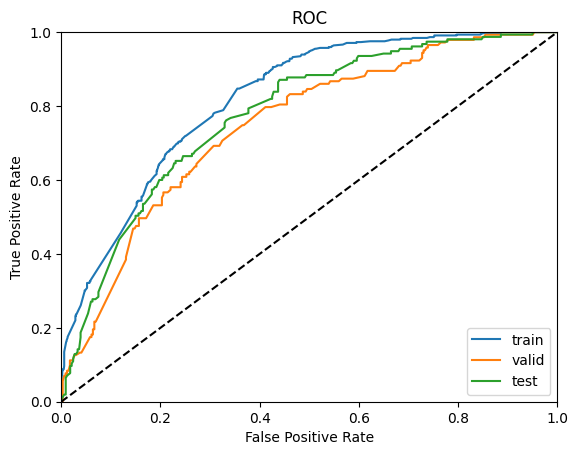

In [575]:
# Предсказываем вероятности
predictions_prob_train = model.predict_proba(features_df_train)
predictions_prob_one_train = predictions_prob_train[:, 1] # Выбираем вероятности отнесения к классу "1"
print(roc_auc_score(target_df_train, predictions_prob_one_train), 2*roc_auc_score(target_df_train, predictions_prob_one_train)-1)

predictions_prob_valid = model.predict_proba(features_df_valid)
predictions_prob_one_valid = predictions_prob_valid[:, 1] # Выбираем вероятности отнесения к классу "1"
print(roc_auc_score(target_df_valid, predictions_prob_one_valid), 2*roc_auc_score(target_df_valid, predictions_prob_one_valid)-1)

predictions_prob_test = model.predict_proba(features_df_test)
predictions_prob_one_test = predictions_prob_test[:, 1] # Выбираем вероятности отнесения к классу "1"
print(roc_auc_score(target_df_test, predictions_prob_one_test), 2*roc_auc_score(target_df_test, predictions_prob_one_test)-1)

fpr_1, tpr_1, thresholds_1 = roc_curve(target_df_train, predictions_prob_one_train)
fpr_2, tpr_2, thresholds_2 = roc_curve(target_df_valid, predictions_prob_one_valid)
fpr_3, tpr_3, thresholds_3 = roc_curve(target_df_test, predictions_prob_one_test)
plt.plot(fpr_1, tpr_1, label='train')
plt.plot(fpr_2, tpr_2, label='valid')
plt.plot(fpr_3, tpr_3, label='test')
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")

##### **Baseline**

0.7069672131147541
0.0
0.0
0.0
[[345   0]
 [143   0]]
0.5 0.0


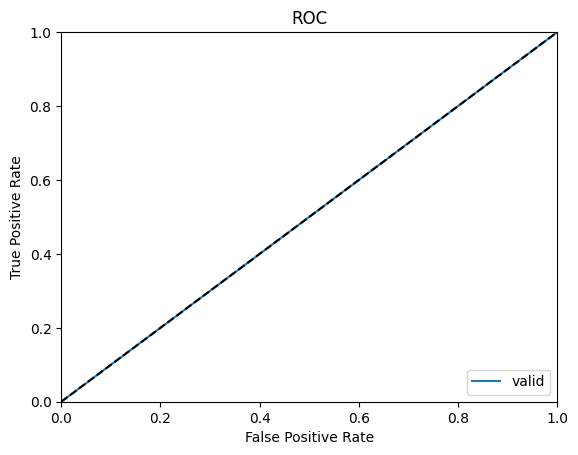

In [576]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(features_df_valid, target_df_valid)
target_pred = dummy_clf.predict(features_df_valid)
print(accuracy_score(target_df_valid, target_pred))
print(f1_score(target_df_valid, target_pred))
print(precision_score(target_df_valid, target_pred))
print(recall_score(target_df_valid, target_pred))
print(confusion_matrix(target_df_valid, target_pred))

# Предсказываем вероятности
predictions_prob_valid = dummy_clf.predict_proba(features_df_valid)
predictions_prob_one_valid = predictions_prob_valid[:, 1] # Выбираем вероятности отнесения к классу "1"
print(roc_auc_score(target_df_valid, predictions_prob_one_valid), 2*roc_auc_score(target_df_valid, predictions_prob_one_valid)-1)

fpr_2, tpr_2, thresholds_2 = roc_curve(target_df_valid, predictions_prob_one_valid)
plt.plot(fpr_2, tpr_2, label='valid')
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right");

### **Вывод**

Для борьбы с дисбалансом классов была применена техника upsampling. Были исследованы модели Decision Tree Classifier и Random Forest Classifier. Наилучшее качество показал Random Forest Classifier с гиперпараметрами n_estimators=4, max_depth=5, подобранными на кроссвалидации. Модель была проверена на тестовой выборке и показала результат F1 score = 0.59. У выбранной модели показатель AUC_ROC = 0.75, что выше, чем у baseline (0.5), т.е. модель прошла проверку на адекватность.

### **Используемые материалы**

[Лекция Яндекс Кружка по деревьям](https://disk.yandex.ru/d/2JnF6qwRCF46mg/%D0%98%D1%81%D0%BA%D1%83%D1%81%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%8B%D0%B9%20%D0%B8%D0%BD%D1%82%D0%B5%D0%BB%D0%BB%D0%B5%D0%BA%D1%82/%D0%97%D0%B0%D0%BD%D1%8F%D1%82%D0%B8%D0%B5%205/7%20%D0%B4%D0%B5%D0%BA%D0%B0%D0%B1%D1%80%D1%8F_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F.mp4)